# Spectral comparison of putative layers

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import gmean
from scipy.stats import mannwhitneyu
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter

## Parameters

In [3]:
with open("/CSNG/studekat/ripple_paper_clean/code/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DATA_FOLDER = '/CSNG/Ephys_data/Macaque_data/' ### folder with all the preprocessed data
DATES = params_analysis['dates']

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean/dataframes' ### here the resulting dataframes will be saved
MAIN_FOLDER = params_analysis['main_folder']
MONKEY_LIST = ['L','F'] 
AREAS_MERGED = params_analysis['areas_merged']
FINAL_CLASSES = params_analysis['final_classes']
CLASS_COLORS = params_analysis['colors_class']
CLASS_NAMES = params_analysis['classes_names']

AREA = 'V12'

## Functions

In [4]:
def aux_units_on_ch(df_sua_all,array,final_classes=FINAL_CLASSES):
    """
    Returns dictionary with unit types on each of the channels.
    """
    df_arr = df_sua_all[df_sua_all['array']==array]
    ch_dict = {k:[] for k in range(64)}
    for ch in range(64):
        df_arr_ch = df_arr[df_arr['channel_order']==ch]
        for cl in final_classes:
            df_cl = df_arr_ch[df_arr_ch['final_class']==cl]
            num_cl_ch = df_cl.shape[0]
            for i in range(num_cl_ch):
                ch_dict[ch].append(cl)
    return ch_dict

In [5]:
def aux_dominant_clique_on_ch(ch_dict):
    """
    Given the distribution of units per channel decides which clique it belongs to.
    """
    clique_dict = {}
    for ch in range(64):
        ch_classes = ch_dict[ch]
        count_orange = sum(v in ['DOWN_wide', 'DOWN_narrow_shallow','DOWN_medium_shallow'] for v in ch_classes)
        count_blue = sum(v in ['UP', 'DOWN_wide','DOWN_narrow_sharp','DOWN_medium_sharp'] for v in ch_classes)
        if count_orange<1 & count_blue<1:
            clique_dict[ch] = 'white'
        elif count_orange>count_blue:
            clique_dict[ch] = 'orange'
        elif count_orange<count_blue:
            clique_dict[ch] = 'blue'
        else:
            clique_dict[ch] = 'gray'
    return clique_dict

In [6]:
def cut_out_LFP(lfp_block,trial_csv,buffer=200):
    """
    Out of the LFP block cuts out only T buffer part before stimulation onset.
    Returns list of LFP blocks, each with 64 rows (channels).
    """
    times_ms = np.int64(df_trial['Trial_start_absolute_s'].values*1000)
    start_t_ms = np.int64(lfp_block.segments[0].t_start.rescale('ms').magnitude)
    lfp_arr = sig_block_to_arr(lfp_block,'LFP_zsc')
    times_ms_shifted = times_ms - start_t_ms
    lfp_arr_list = [lfp_arr[:,t - buffer : t] for t in times_ms_shifted if t - buffer >= 0]
    return lfp_arr_list

In [7]:
def cut_out_LFP_EO(lfp_block,monkey,date,EO_indic,params={}):
    """
    Out of the LFP block cuts out only EO part and concatenates.
    Returns one LFP arr with 64 rows (channels).
    """
    lfp_arr = sig_block_to_arr(lfp_block,'LFP_zsc')
    start_t_ms = np.int64(lfp_block.segments[0].t_start.rescale('ms').magnitude)
    lfp_arr = cut_abs_times(lfp_arr,start_t_ms,monkey,'RS',date,params) # only common times
    common_len = np.min([lfp_arr.shape[1],EO_indic.shape[0]]) # sometimes indicator and cut differ by 1 ms
    lfp_EO = lfp_arr[:,:common_len][:,EO_indic[:common_len]]
    return lfp_EO

In [8]:
def aux_split_idx(clique_dict):
    """
    Returns indices of blue and orange cliques.
    """
    blue_keys = [k for k, v in clique_dict.items() if v == 'blue']
    orange_keys = [k for k, v in clique_dict.items() if v == 'orange']
    return blue_keys, orange_keys

In [9]:
def aux_split_lfp(lfp_arr,blue_cl_idx,orange_cl_idx):
    """
    Out of the list with blocks of LFP cut out single channel LFP, 
    and splits into three lists - orange, blue, and the rest.
    """
    blue_lfps   = lfp_arr[blue_cl_idx,:]
    orange_lfps = lfp_arr[orange_cl_idx,:]
    other_mask = ~np.isin(np.arange(64), np.concatenate([blue_cl_idx, orange_cl_idx]))
    other_lfps = lfp_arr[other_mask,:]
    return blue_lfps, orange_lfps, other_lfps

In [10]:
def spectrum_list(lfp_arr,nperseg):
    """
    Takes as an input list of cut out LFP, 
    returns list of their spectra.
    """
    f, psds = welch(lfp_arr, fs=1000, axis=1, nperseg=nperseg)
    return psds, f

In [11]:
def aux_pick_f_psd(aux_dict,monkey,f,f_min,f_max,mean_for_array=False):
    """
    Cutting out only chosen frequencies out of precalculated psds.
    """
    data = aux_dict[monkey]
    data = [a for a in data if a.shape[0]>0]
    if mean_for_array:
        data = [np.mean(a,axis=0) for a in data if a.shape[0]>0]
        #print(data[0].shape)
    all_psds = np.vstack(data)
    mask = (f>=f_min) & (f<=f_max)
    return all_psds[:,mask]

In [12]:
def add_sig_bar_from_boxplot(ax, bp, p, box1=1, box2=2, offset=0.05):
    """
    Add a significance bar slightly above the whisker caps of two boxplots.
    offset = fraction of axis range (linear) or multiplicative factor (log).
    """

    # Extract the upper caps for each box
    cap1 = bp['caps'][1].get_ydata()[0]   # upper cap of box 1
    cap2 = bp['caps'][3].get_ydata()[0]   # upper cap of box 2

    # Highest cap
    y_cap = max(cap1, cap2)

    # Compute bar height depending on scale
    if ax.get_yscale() == 'log':
        y = y_cap * (1 + offset)
        y_text = y_cap * (1 + offset * 1.3)
        tick = y * 0.03                     # downward tick length
    else:
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        y = y_cap + offset * y_range
        y_text = y + 0.02 * y_range
        tick = 0.015 * y_range              # downward tick length

    # --- Horizontal bar ---
    ax.plot([box1, box2], [y, y], color='black', linewidth=1.2)

    # --- Downward ticks ---
    ax.plot([box1, box1], [y, y - tick], color='black', linewidth=1.2)
    ax.plot([box2, box2], [y, y - tick], color='black', linewidth=1.2)

    # --- Stars ---
    ax.text((box1 + box2) / 2,
            y_text,
            p_to_stars(p),
            ha='center',
            va='bottom',
            fontsize=12)
    return

In [13]:
def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."

## Analysis - one date, all arrays

In [14]:
NPERSEG = 1024

L
20170725


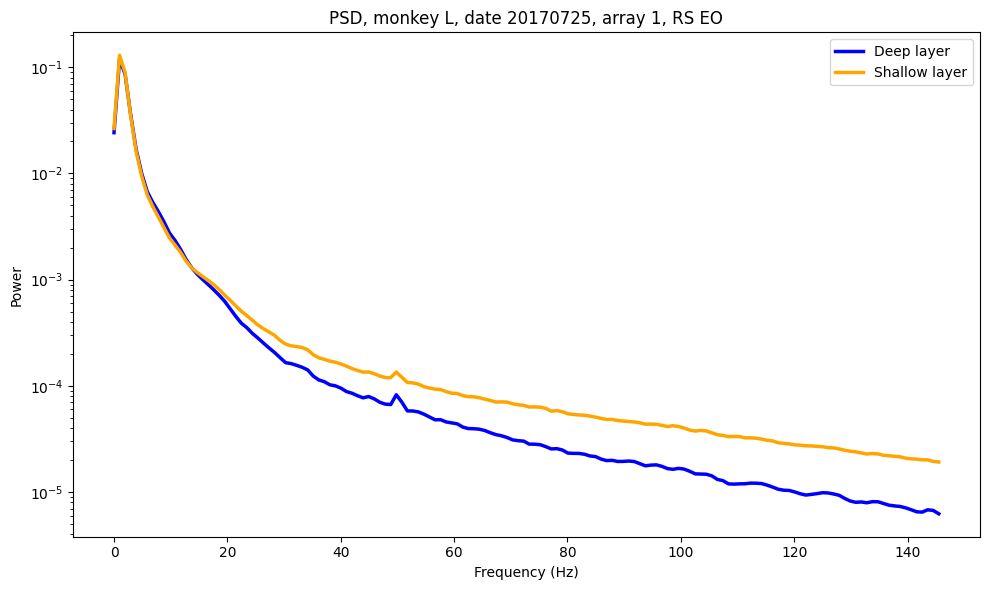

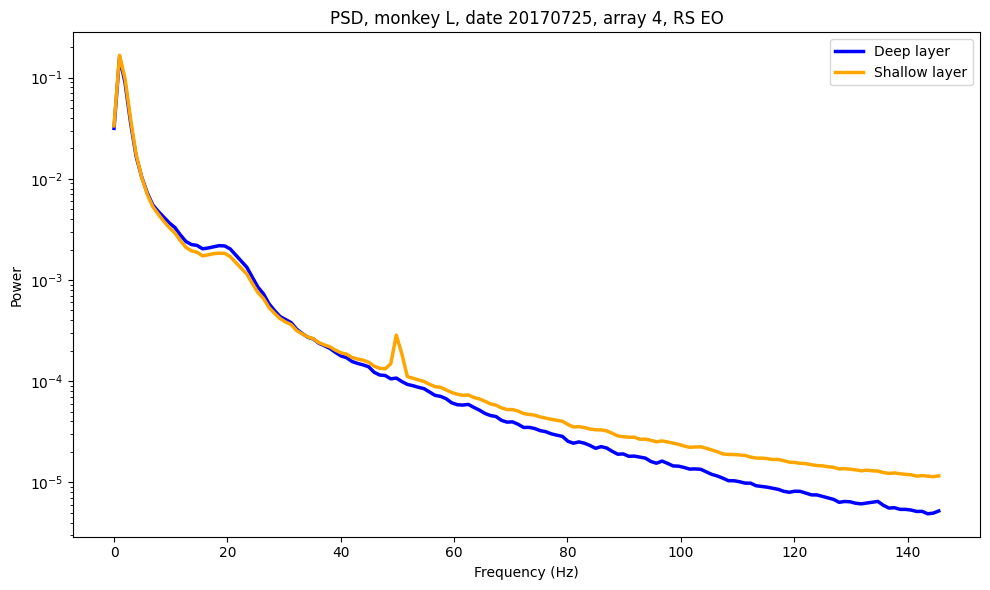

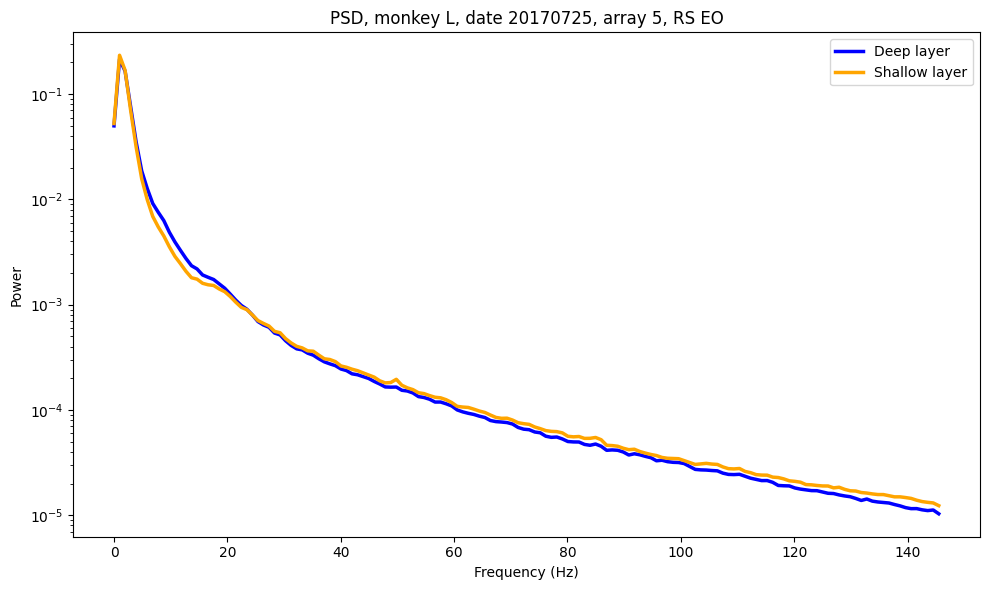

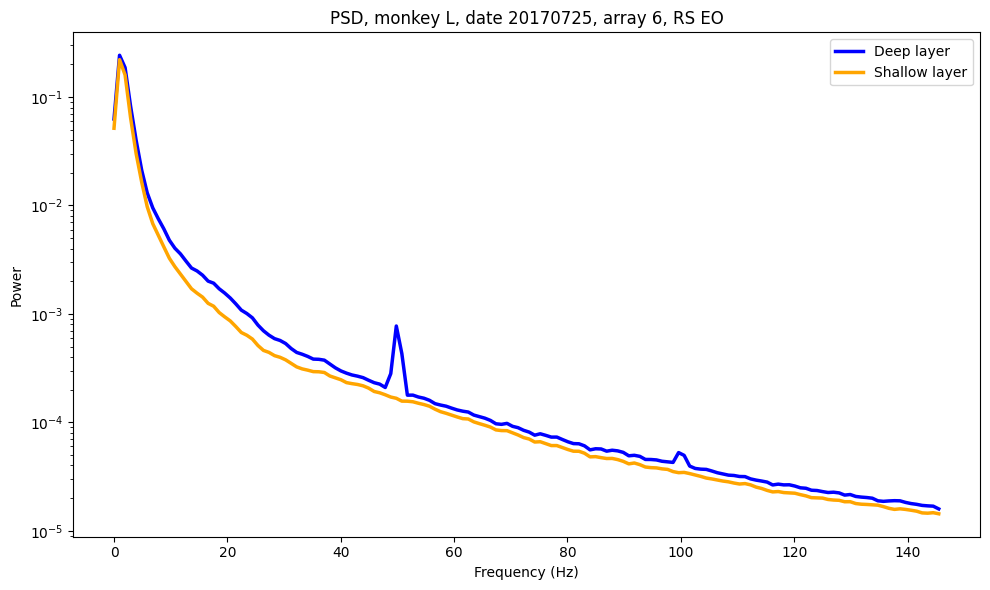

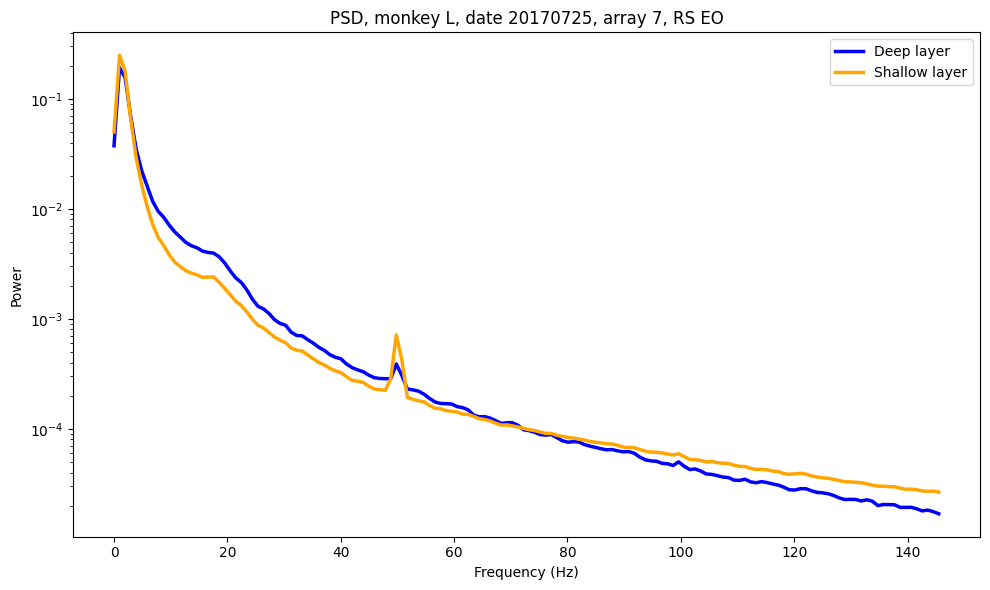

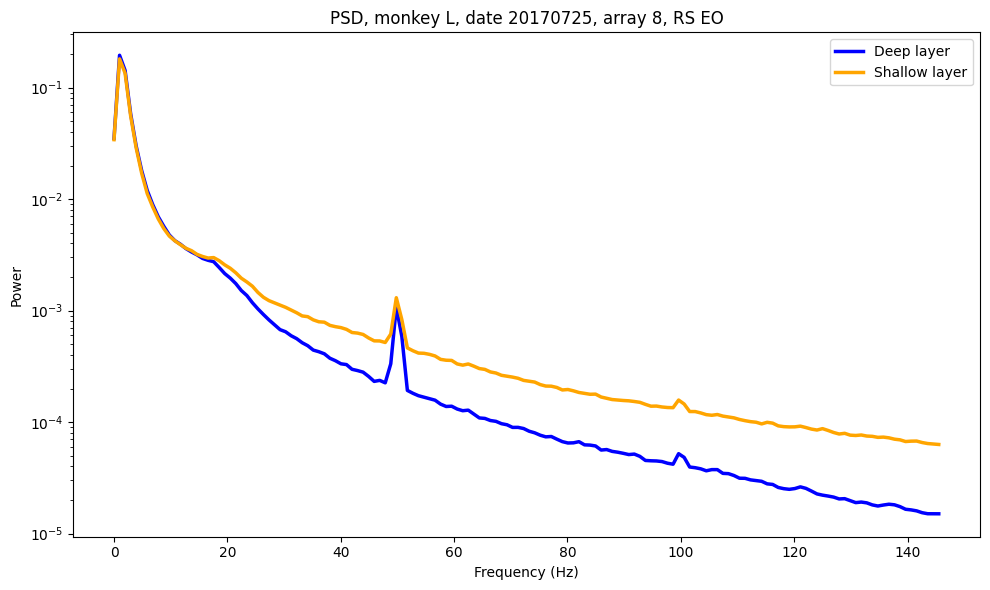

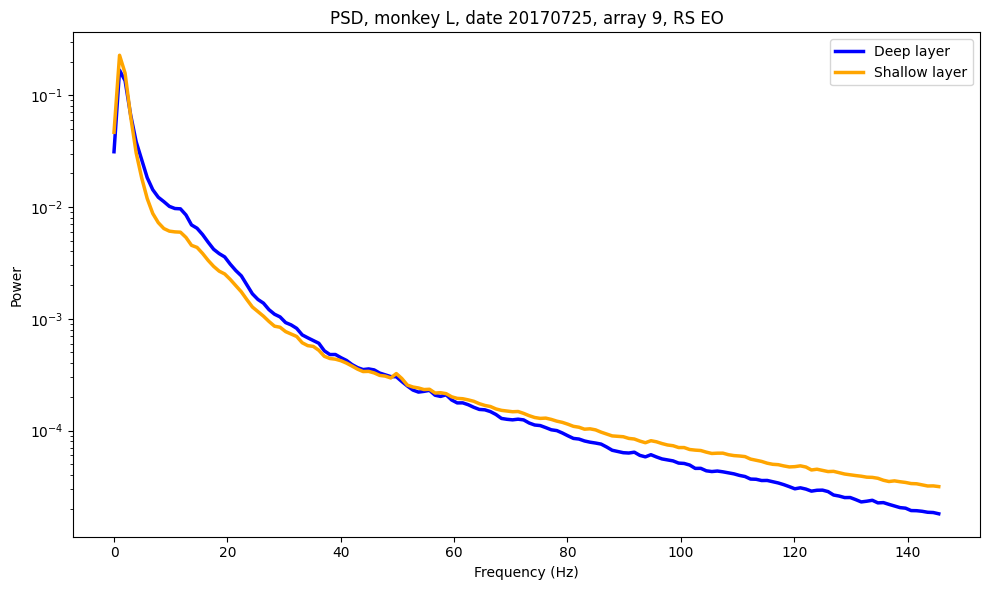

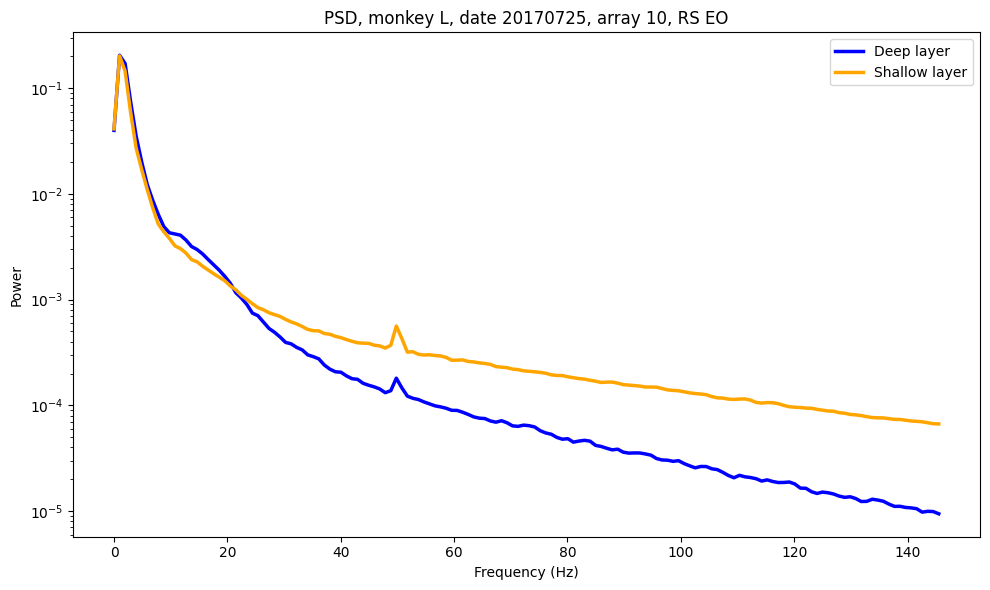

/tmp/ipykernel_2800875/2310349909.py:30: RuntimeWarning: Mean of empty slice.
  mean_blue_psd = blue_psds.mean(axis=0)
/home/studekat/virt_env/work/lib/python3.12/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


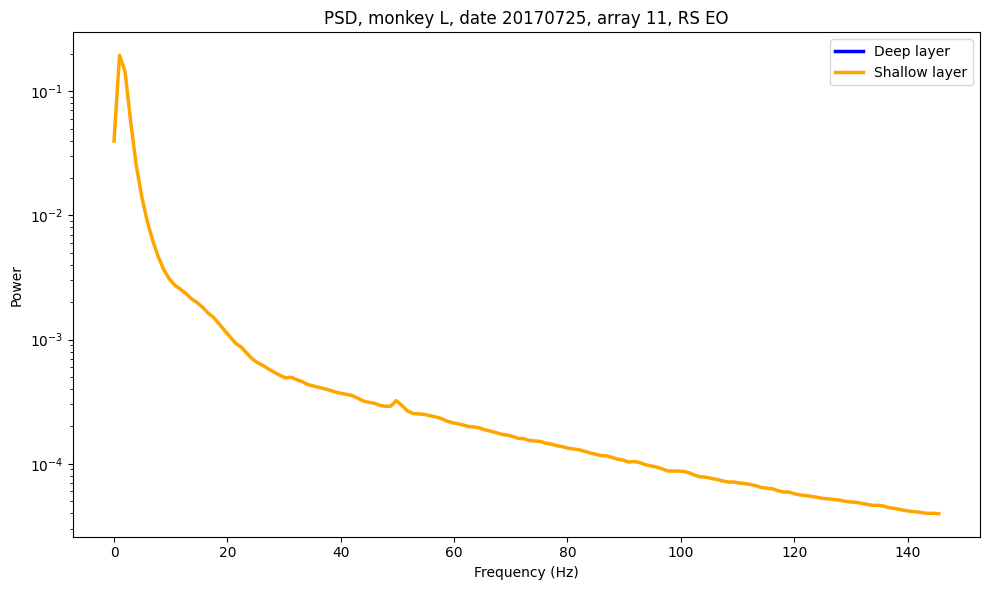

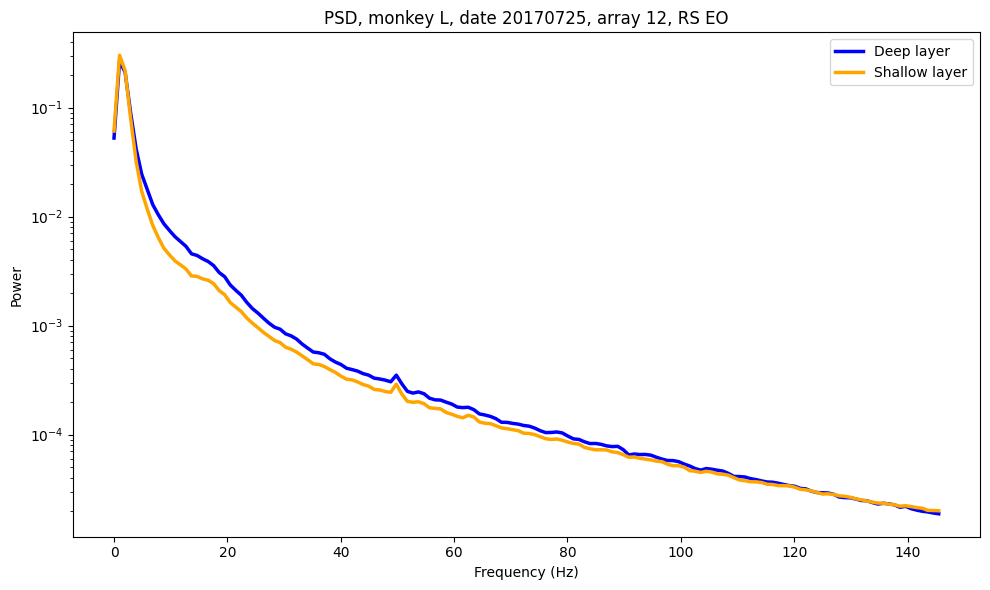

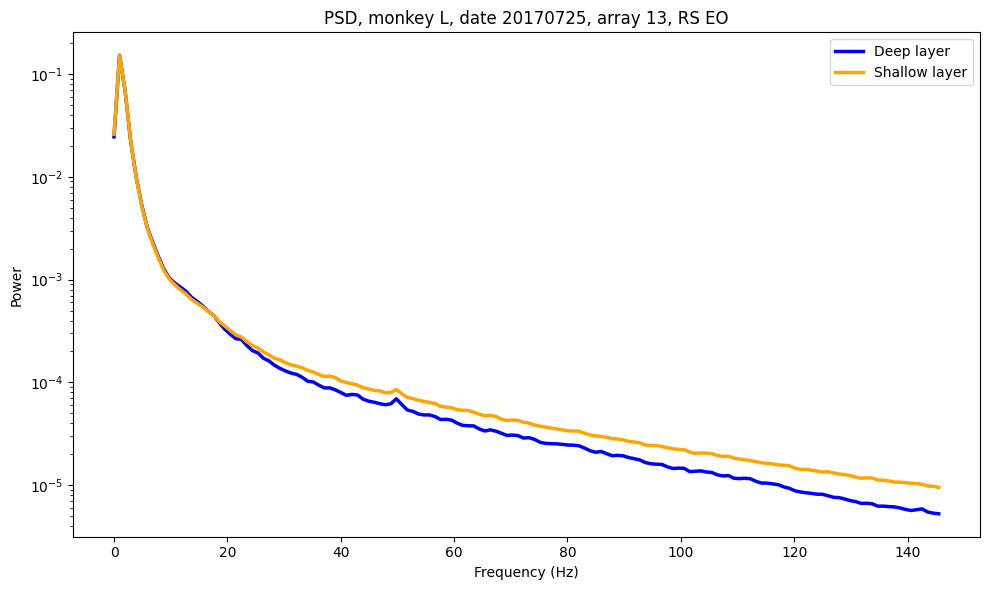

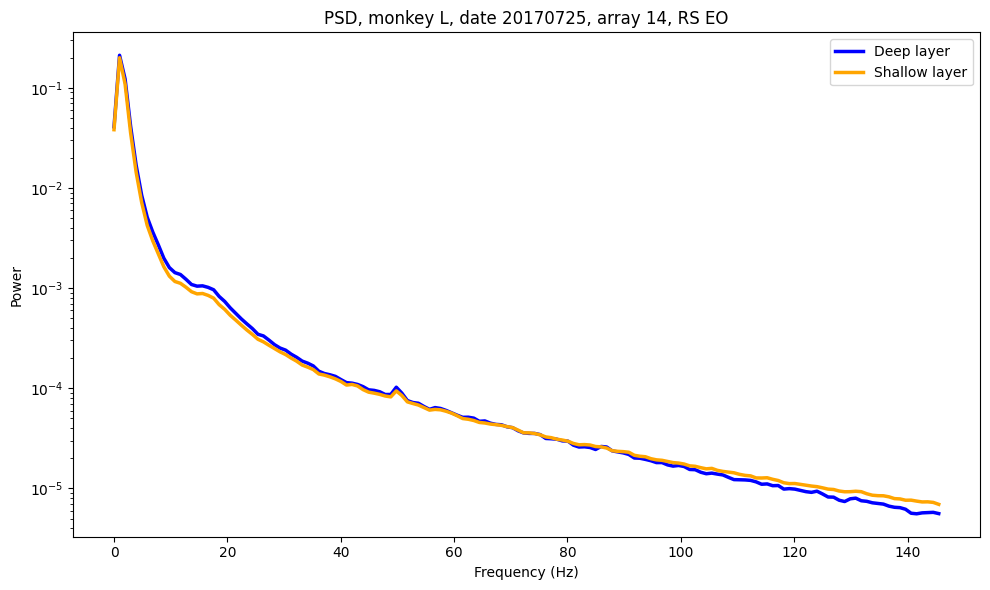

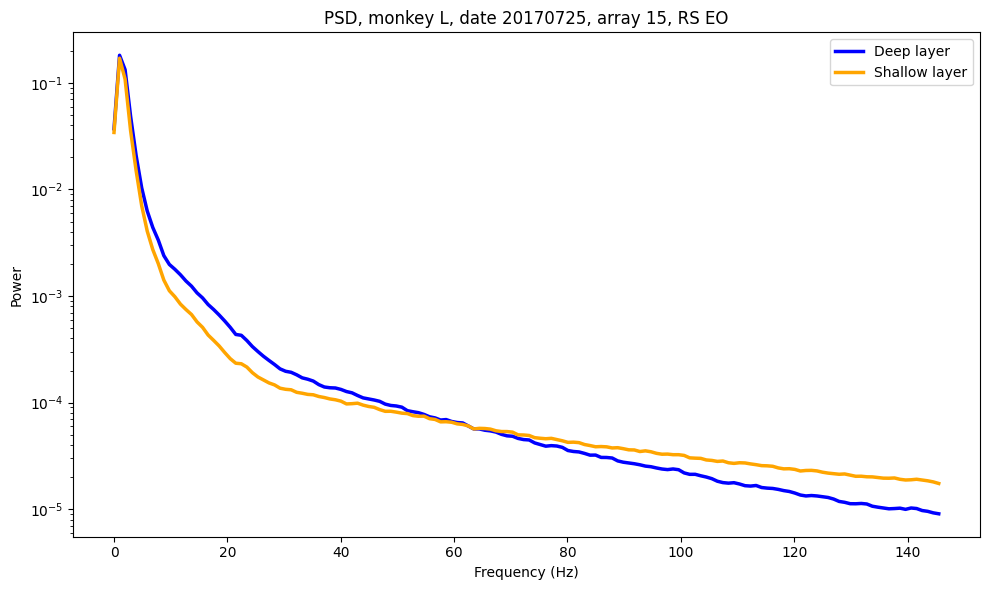

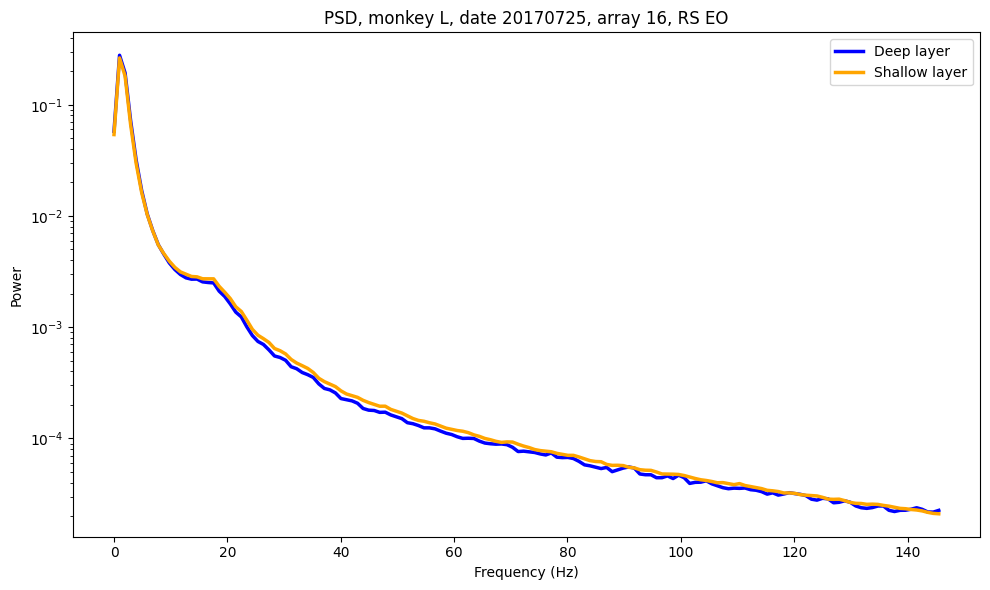

20170809


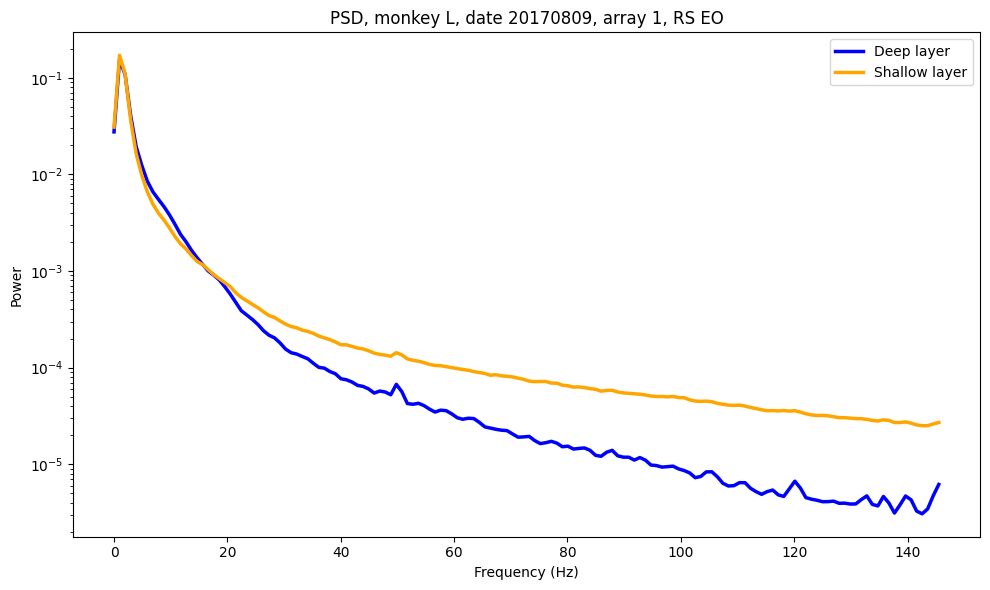

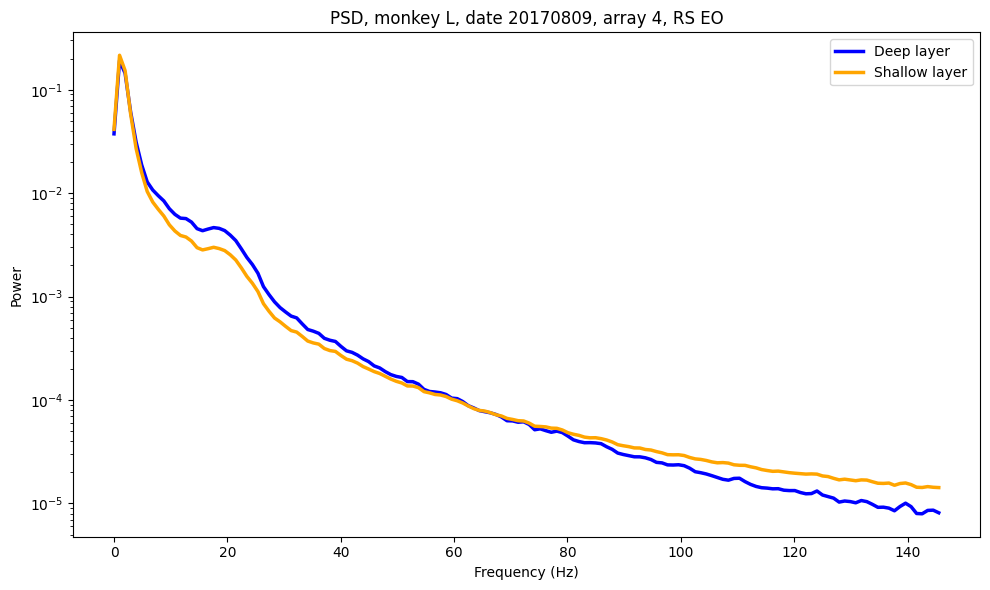

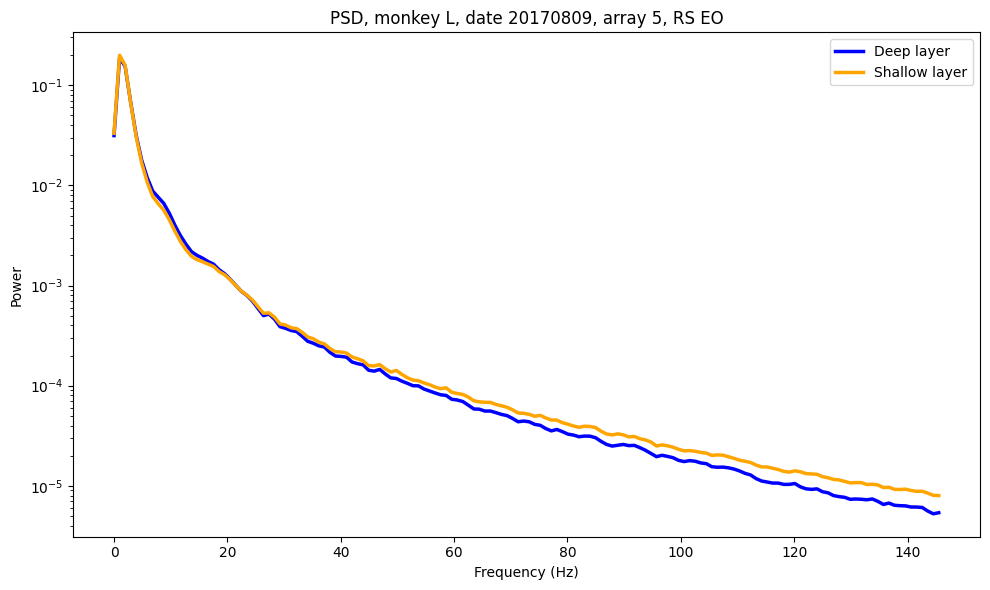

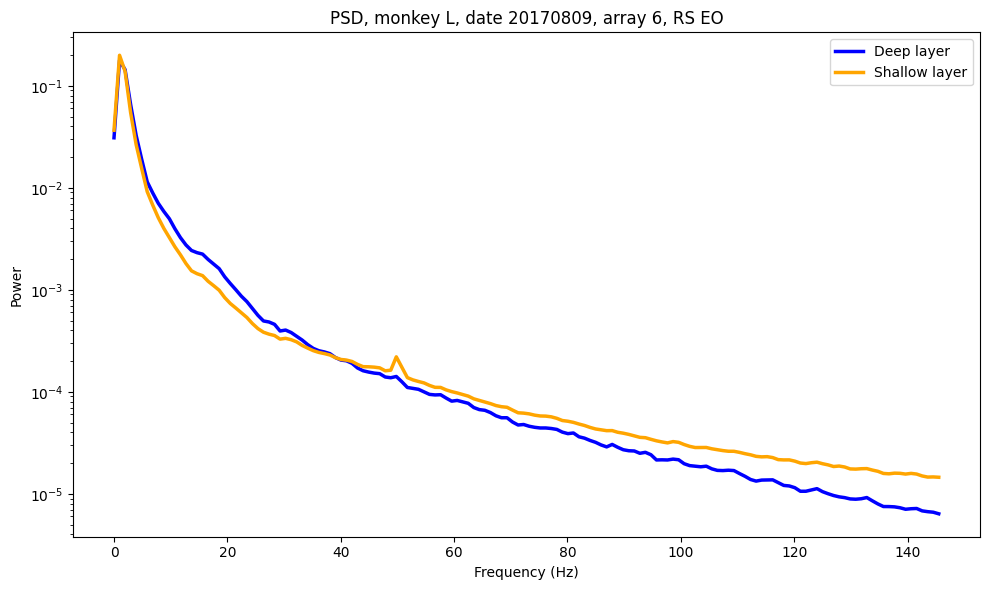

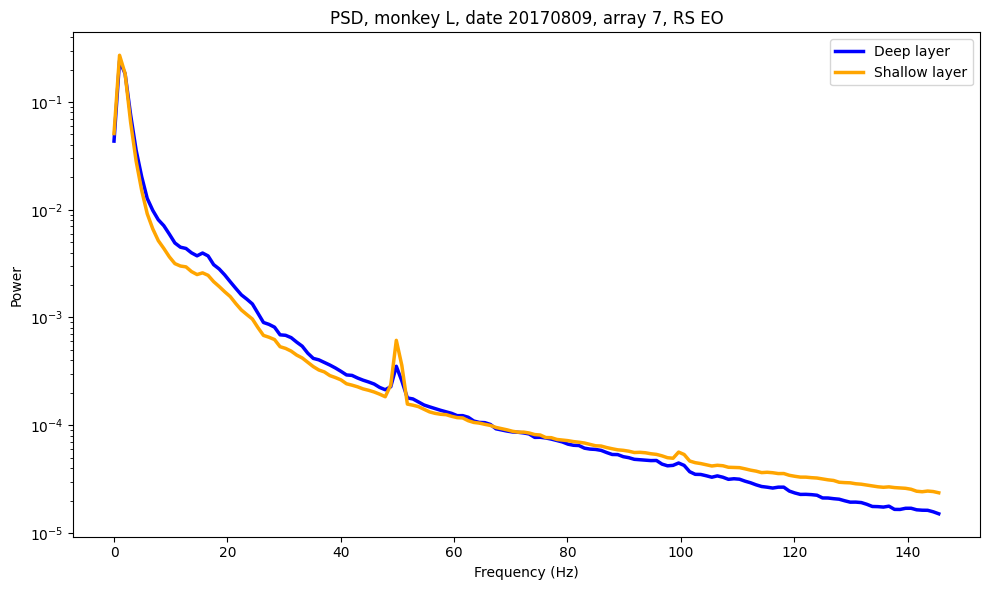

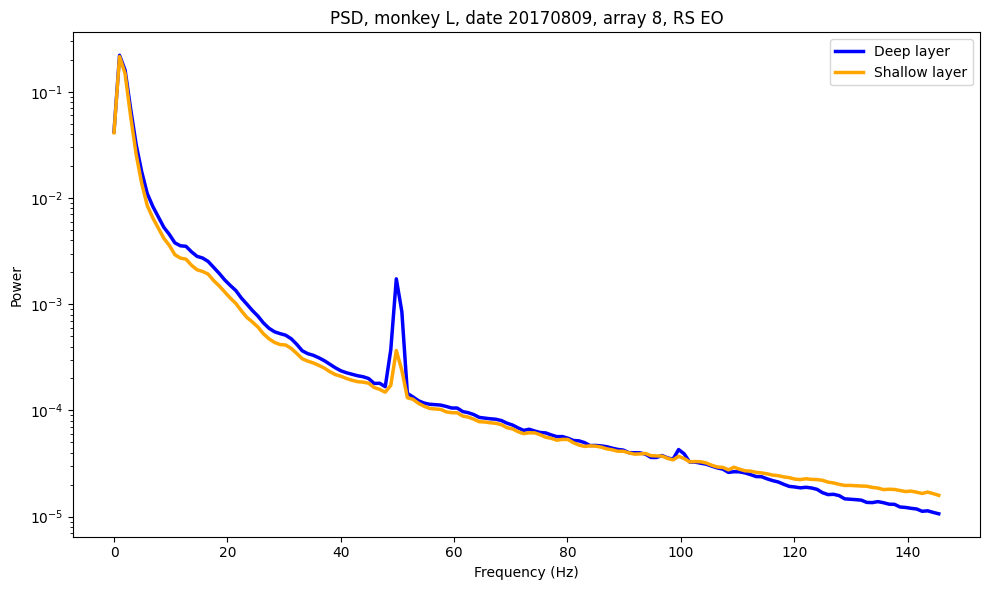

/tmp/ipykernel_2800875/2310349909.py:30: RuntimeWarning: Mean of empty slice.
  mean_blue_psd = blue_psds.mean(axis=0)
/home/studekat/virt_env/work/lib/python3.12/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


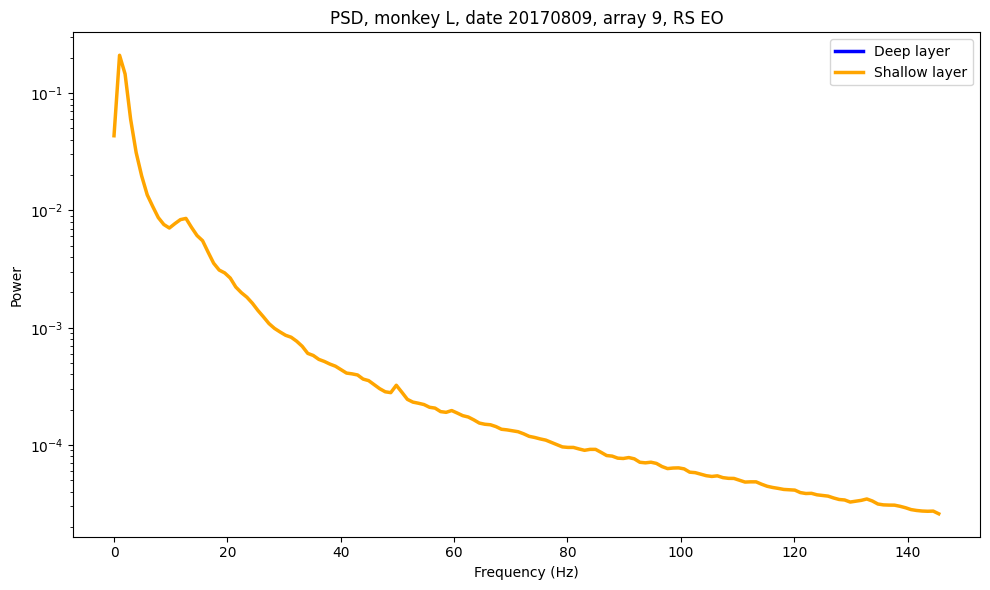

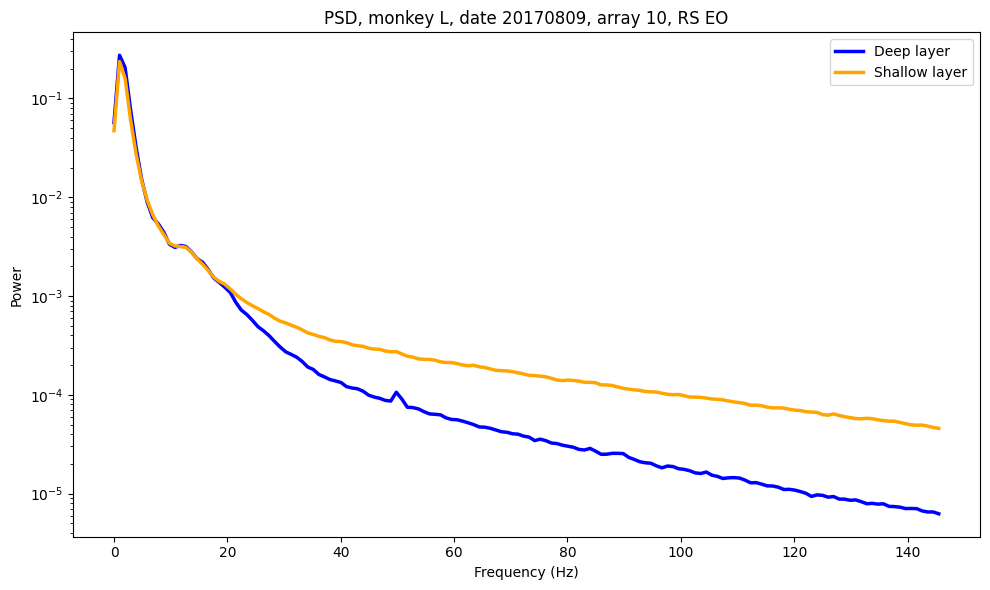

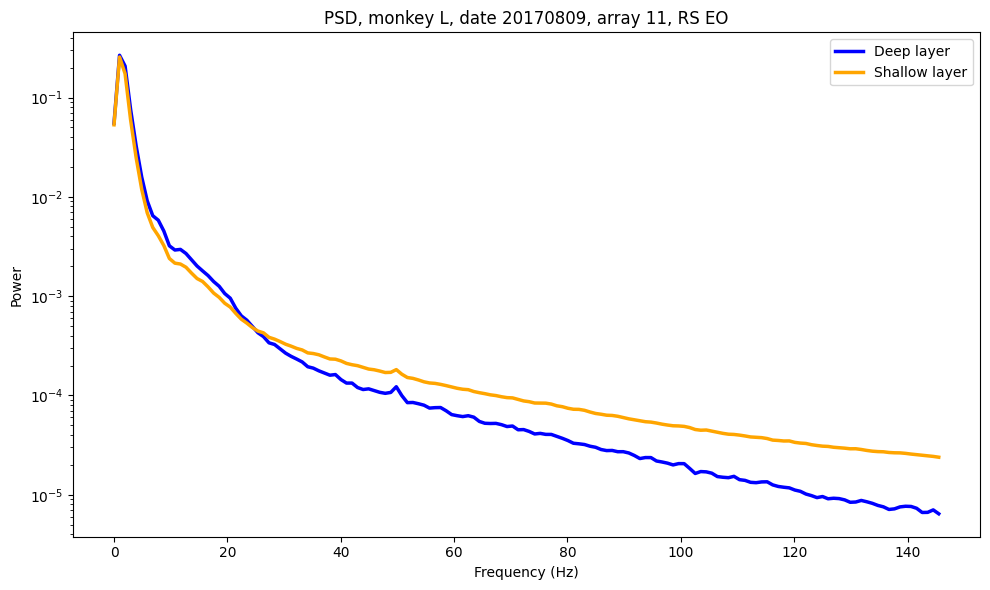

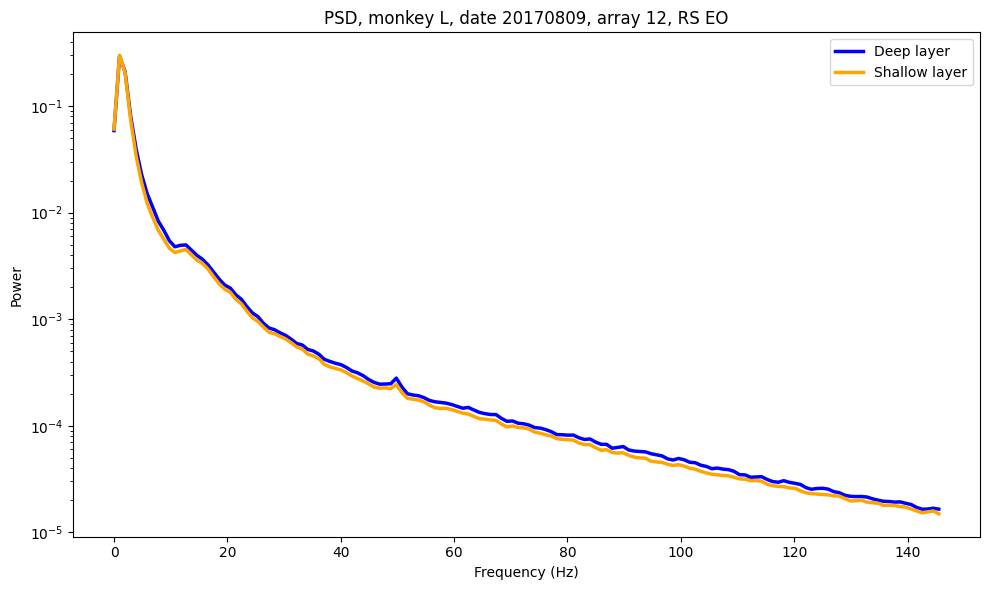

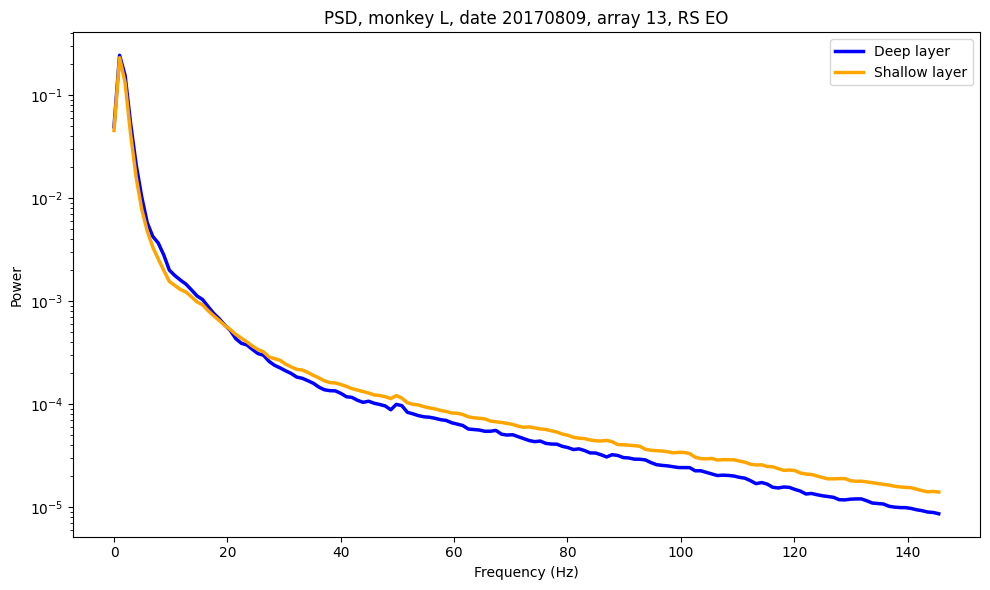

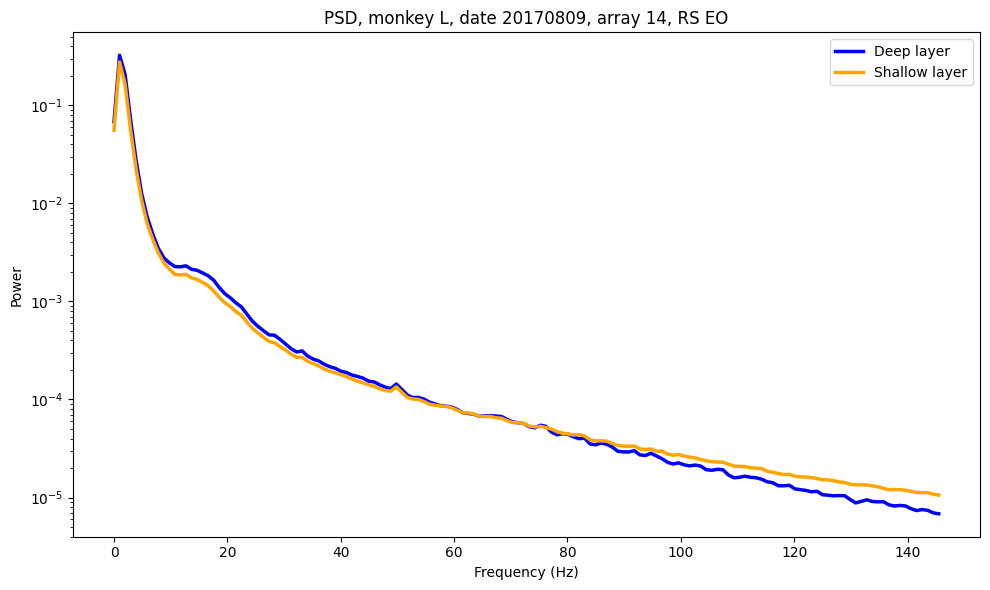

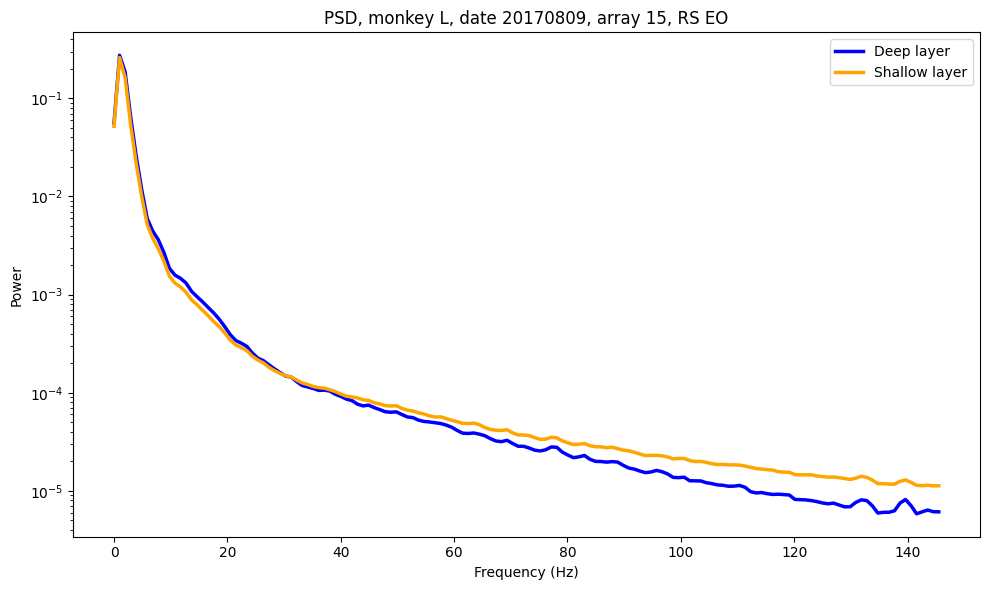

/tmp/ipykernel_2800875/2310349909.py:30: RuntimeWarning: Mean of empty slice.
  mean_blue_psd = blue_psds.mean(axis=0)
/home/studekat/virt_env/work/lib/python3.12/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


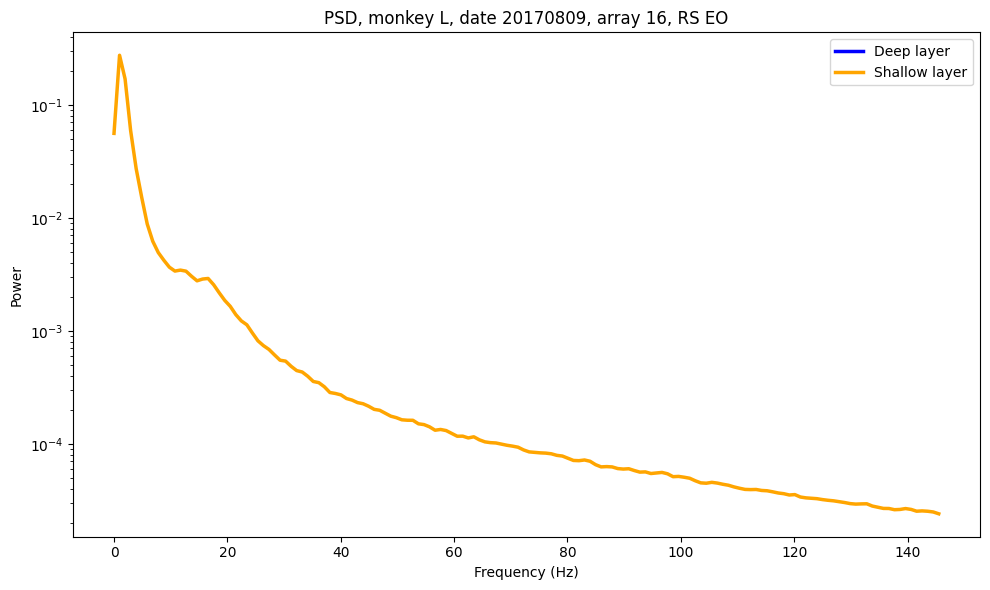

20170810


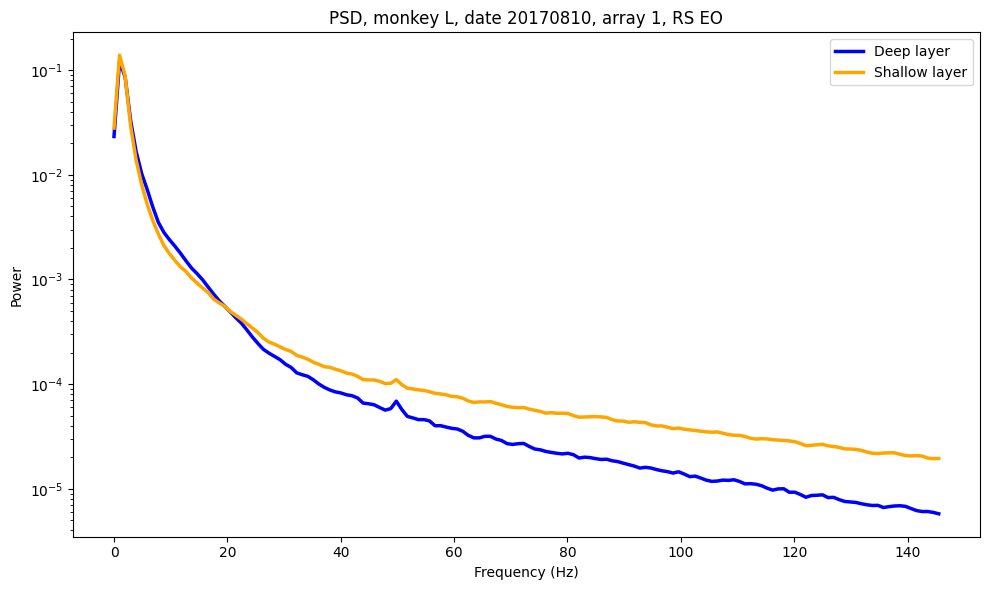

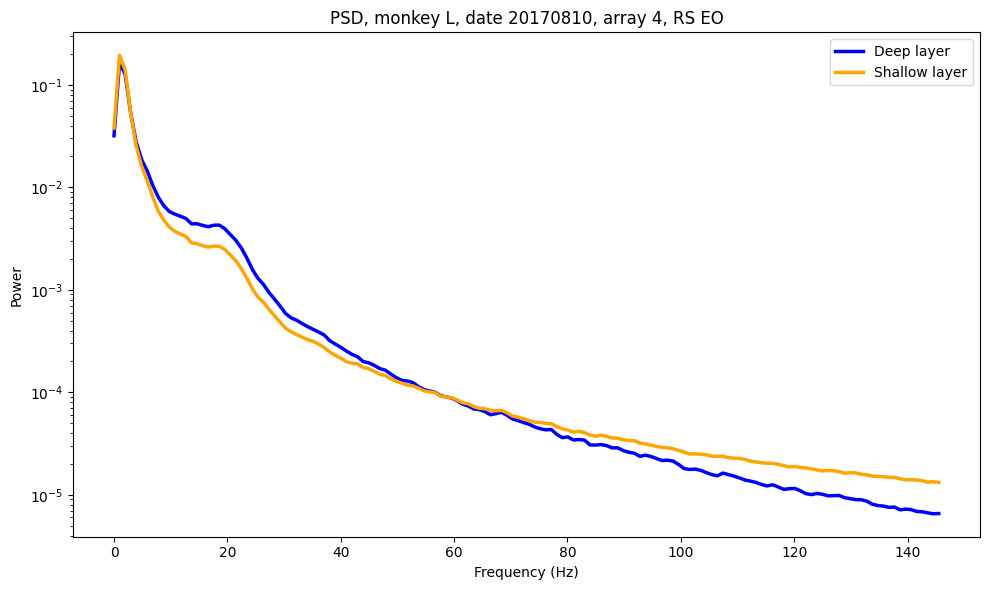

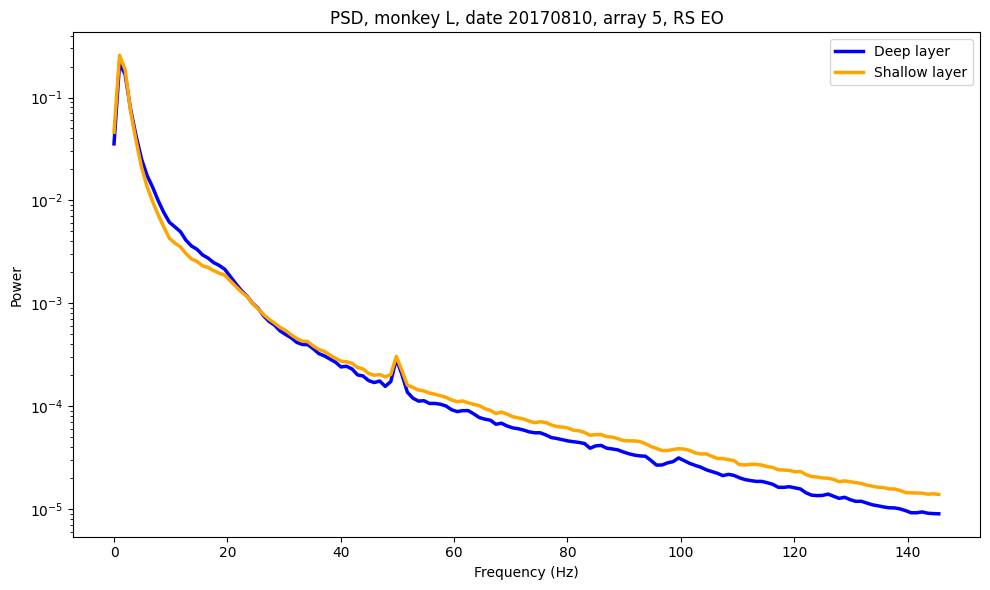

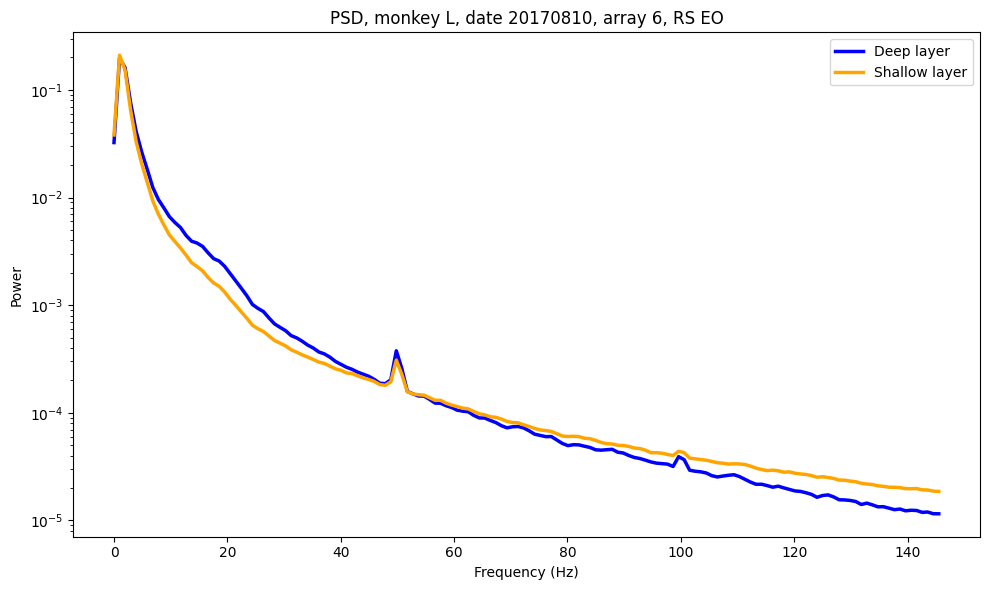

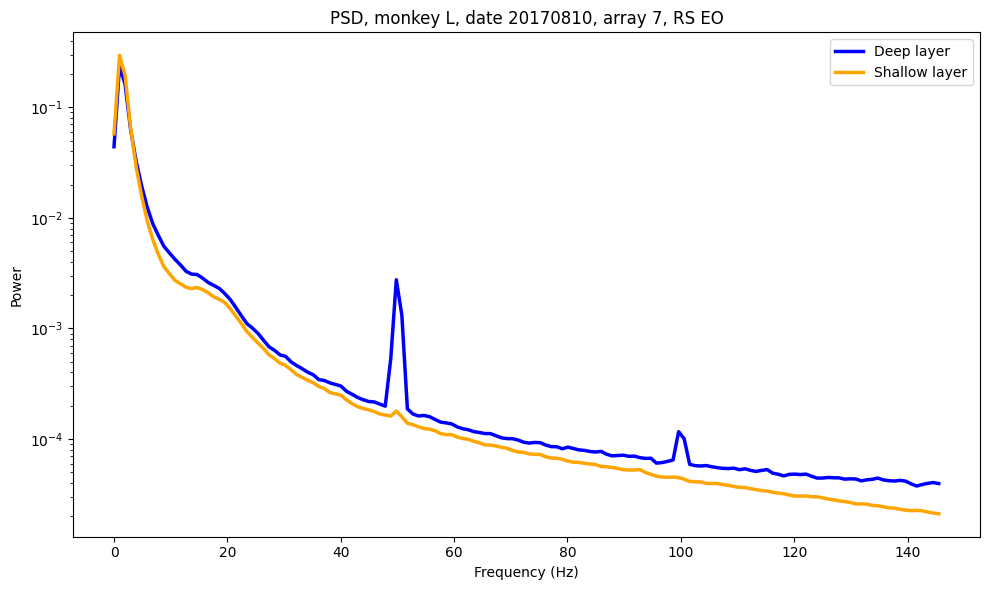

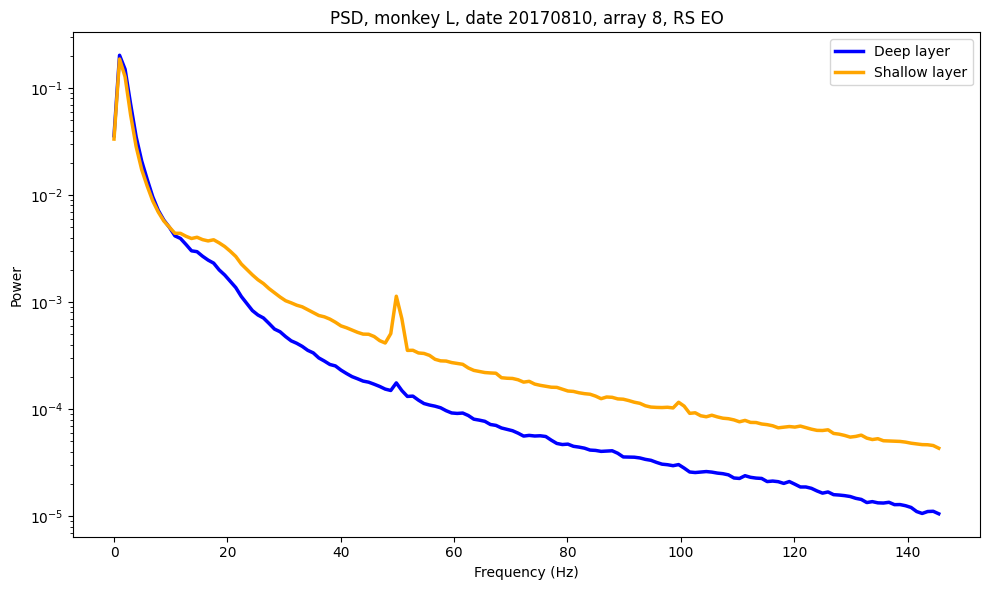

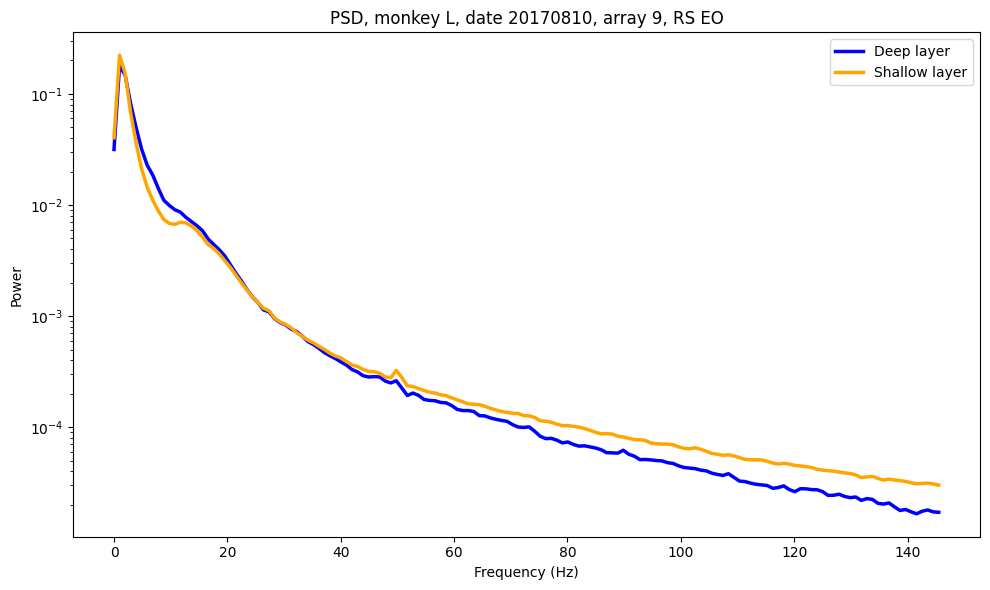

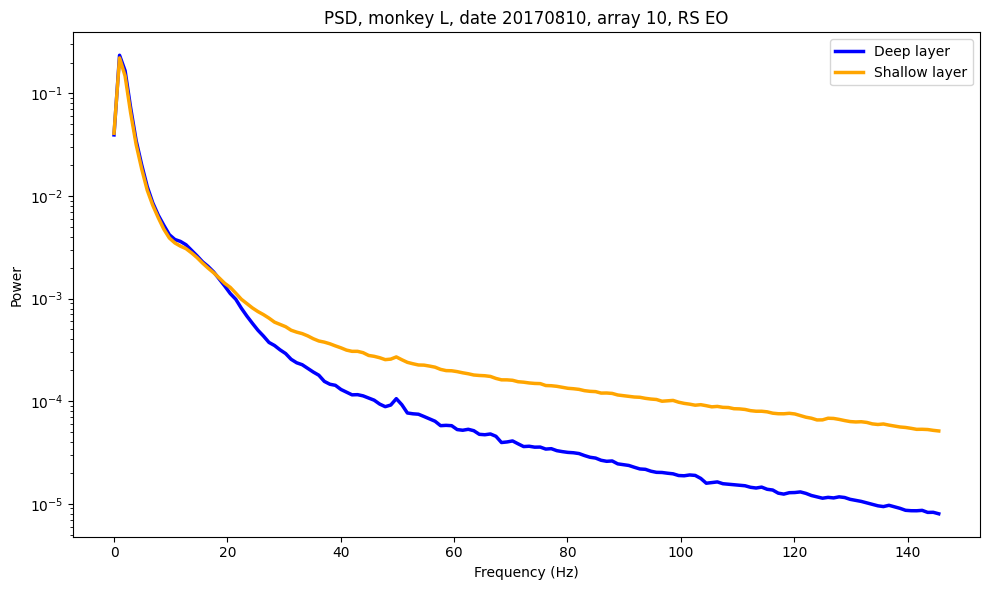

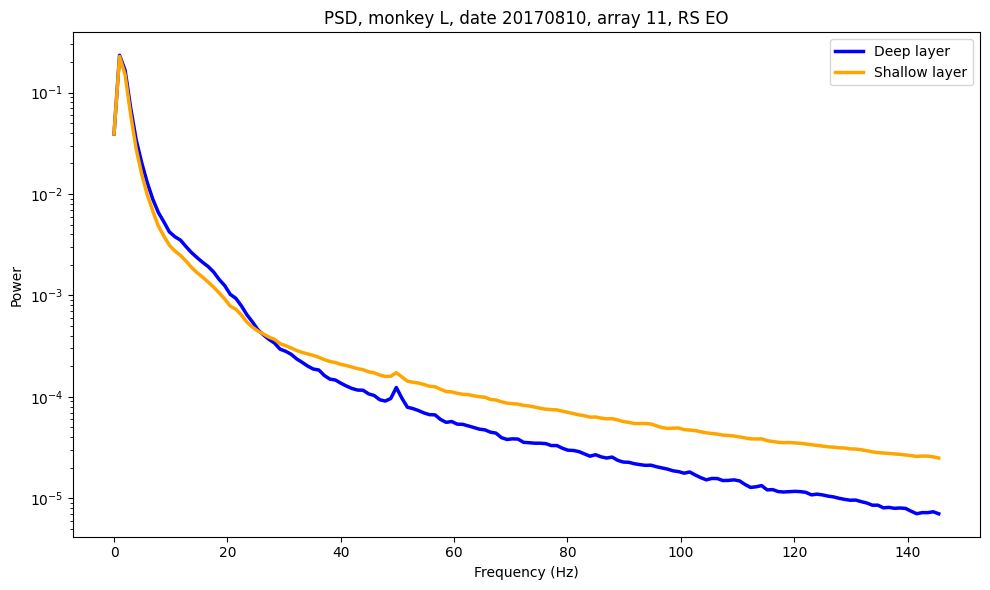

/tmp/ipykernel_2800875/2310349909.py:30: RuntimeWarning: Mean of empty slice.
  mean_blue_psd = blue_psds.mean(axis=0)
/home/studekat/virt_env/work/lib/python3.12/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


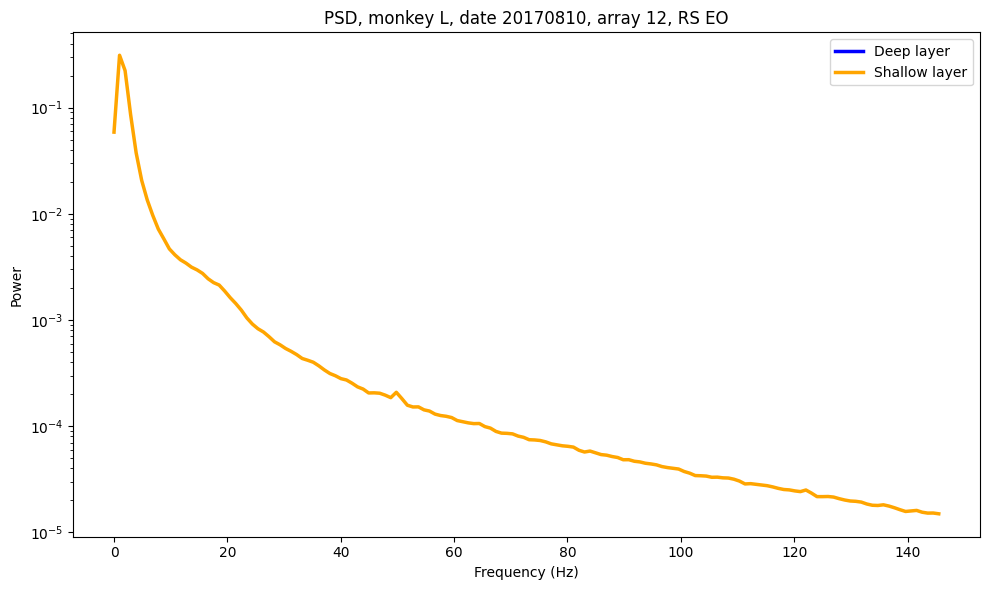

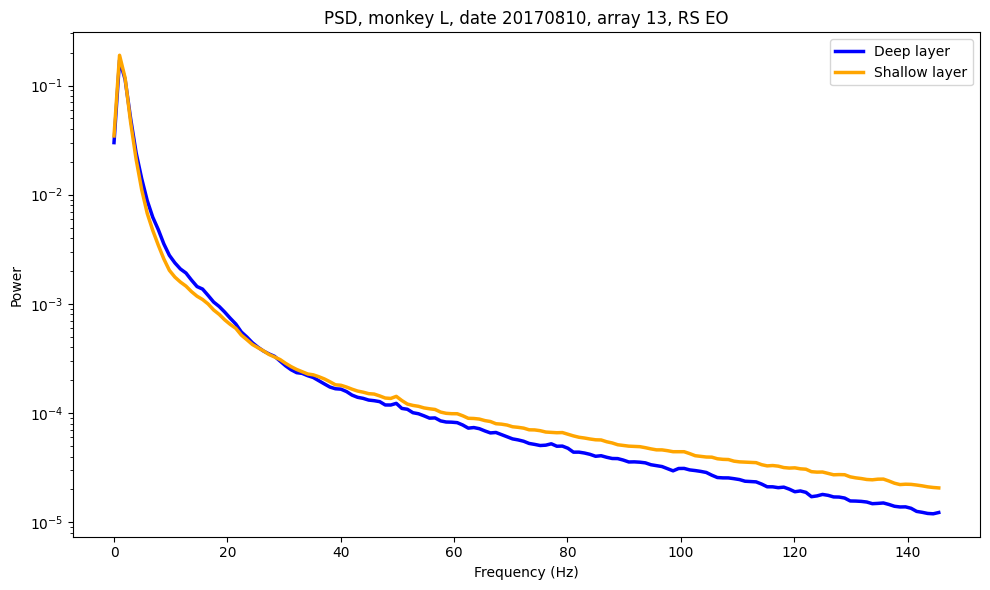

/tmp/ipykernel_2800875/2310349909.py:30: RuntimeWarning: Mean of empty slice.
  mean_blue_psd = blue_psds.mean(axis=0)
/home/studekat/virt_env/work/lib/python3.12/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


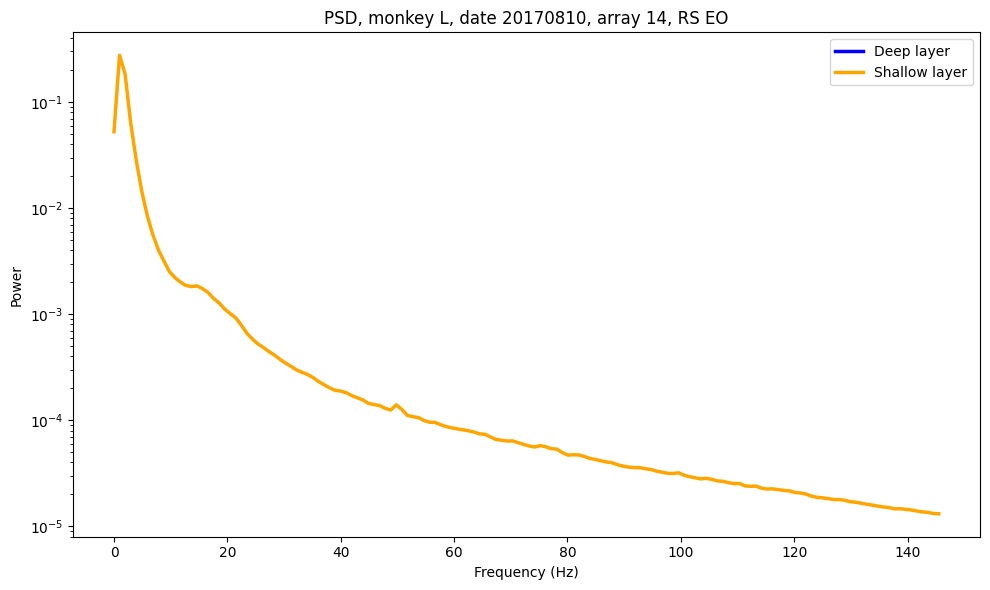

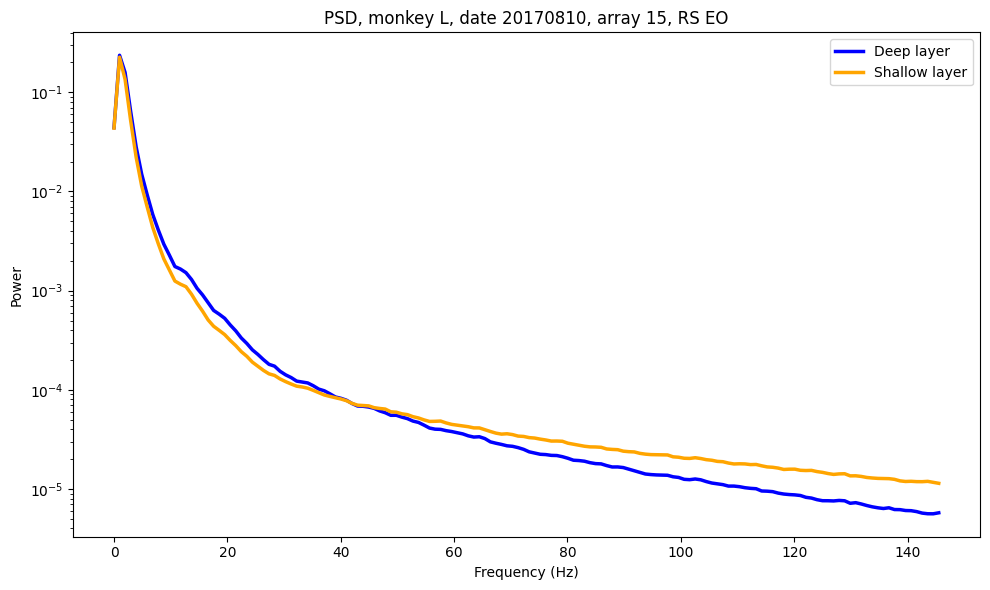

/tmp/ipykernel_2800875/2310349909.py:30: RuntimeWarning: Mean of empty slice.
  mean_blue_psd = blue_psds.mean(axis=0)
/home/studekat/virt_env/work/lib/python3.12/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


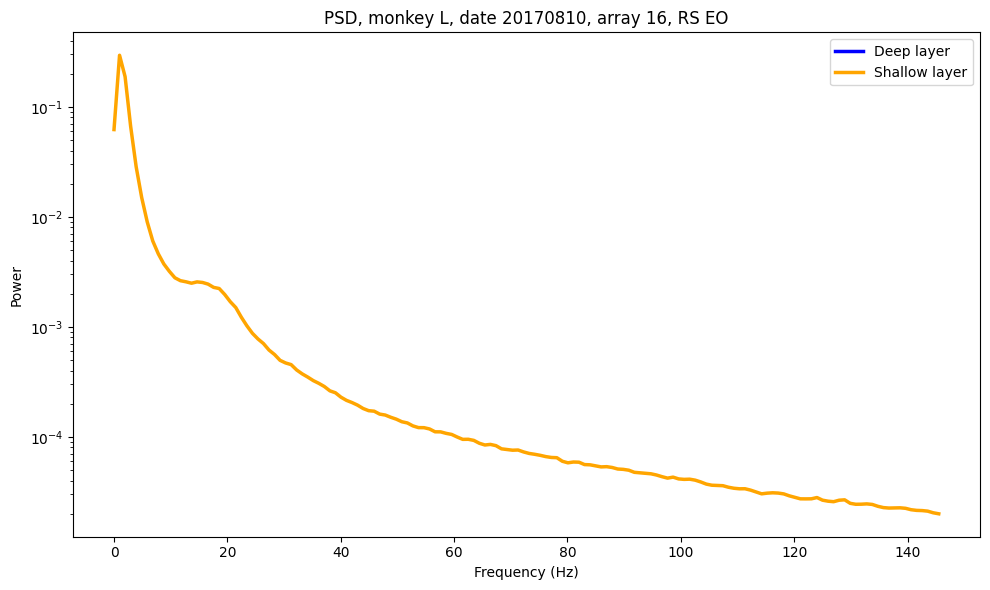

F
20240122_B1


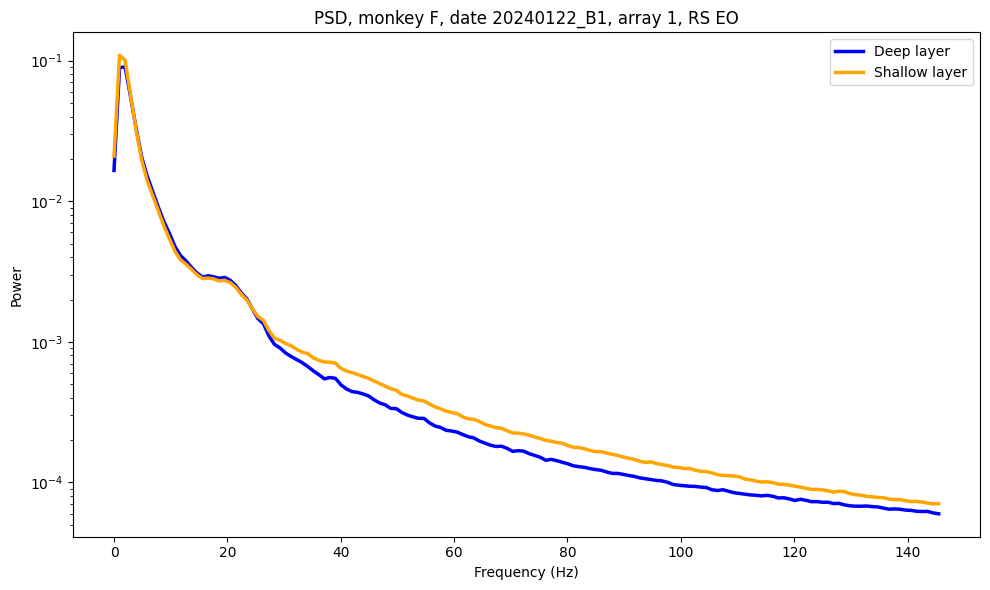

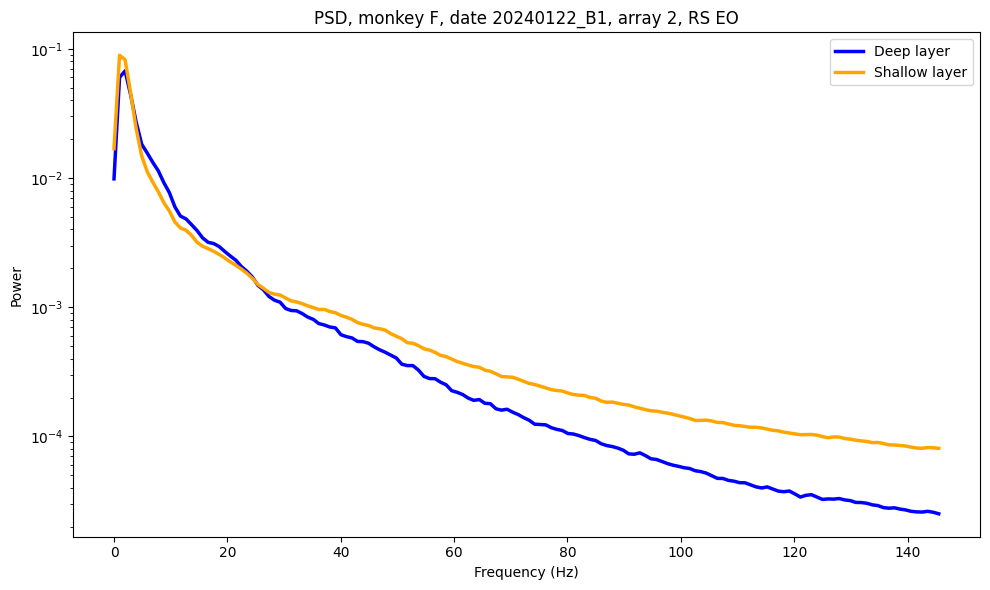

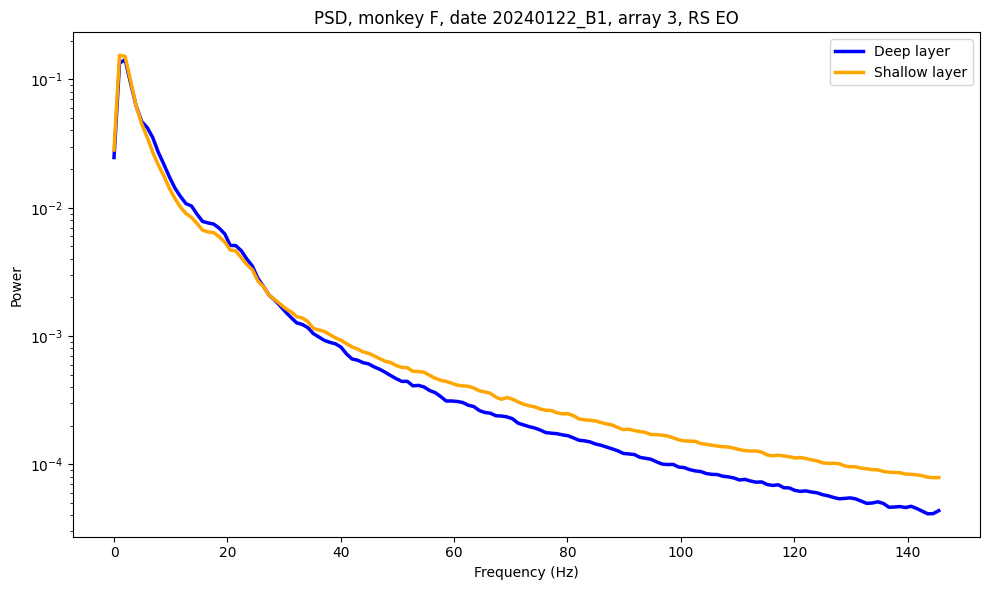

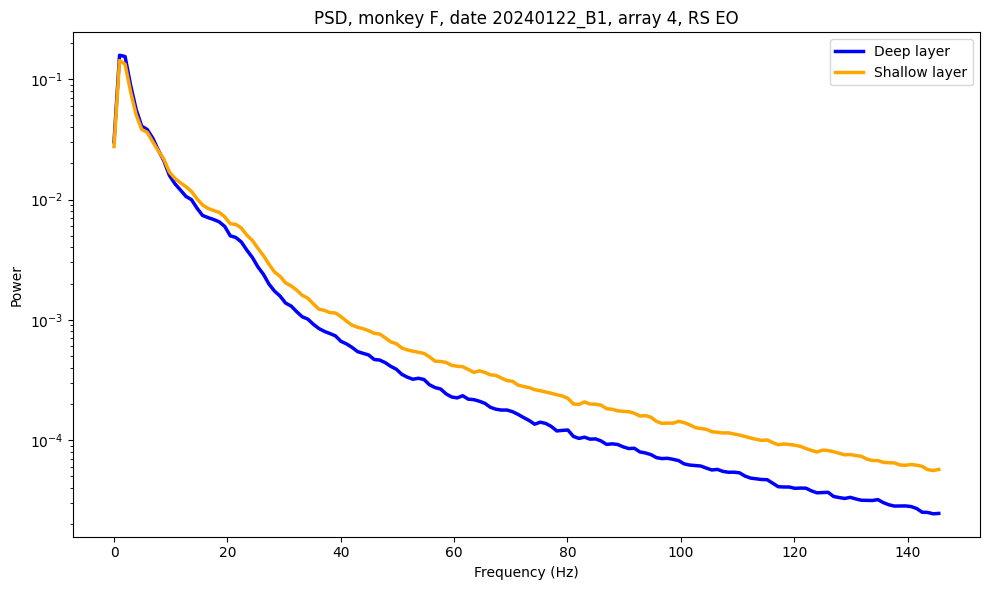

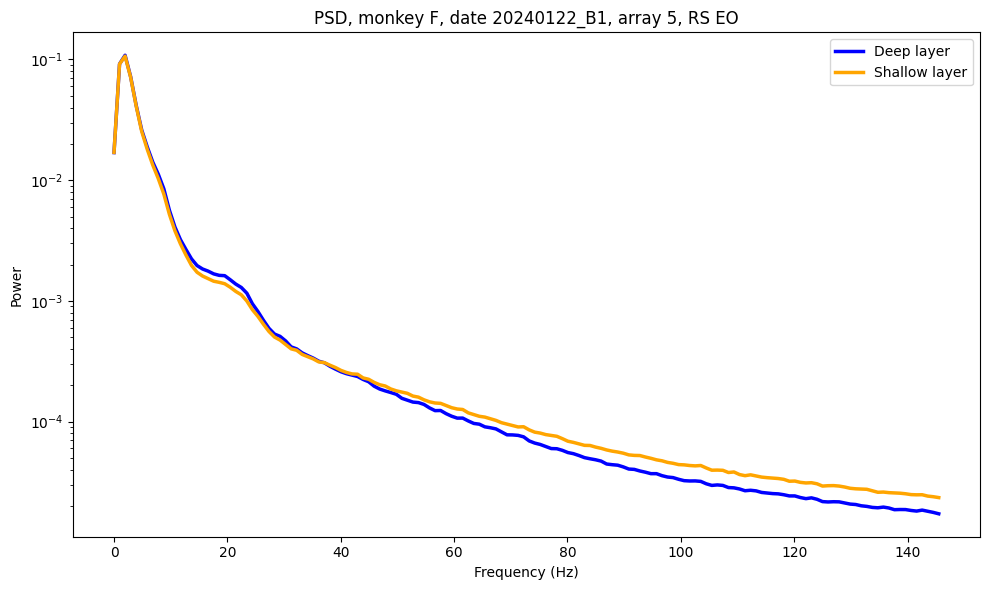

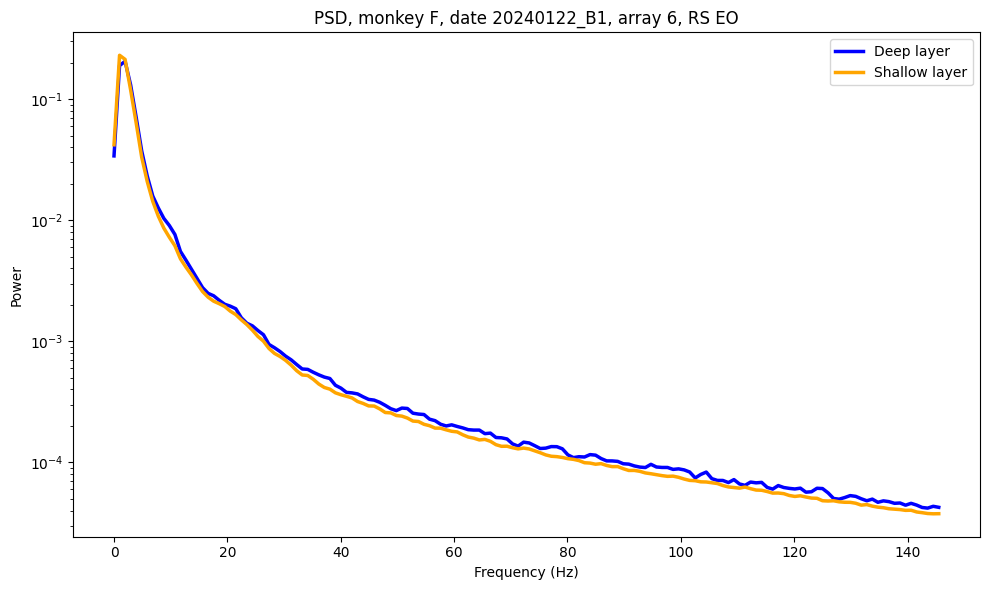

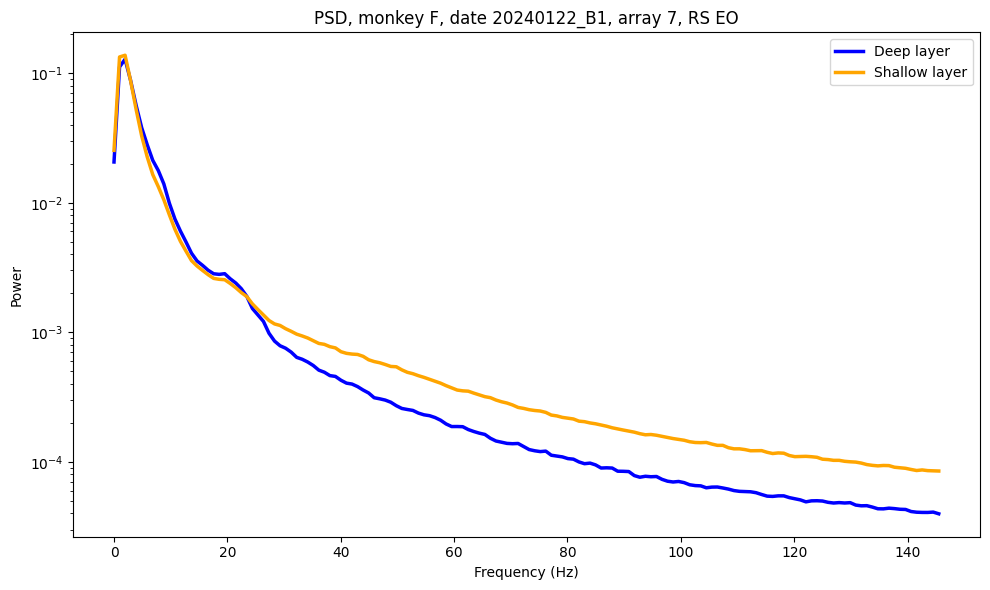

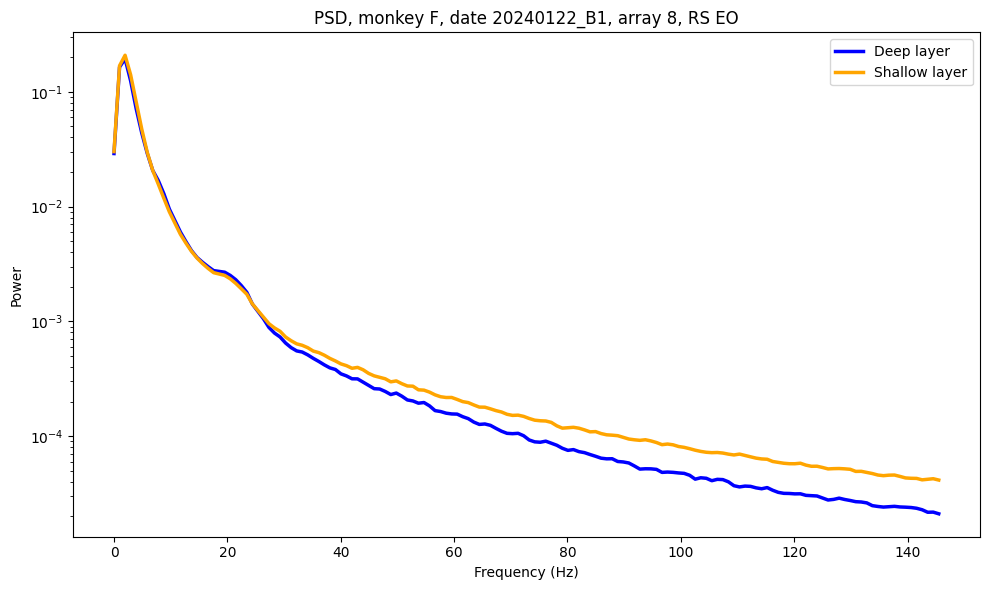

/tmp/ipykernel_2800875/2310349909.py:30: RuntimeWarning: Mean of empty slice.
  mean_blue_psd = blue_psds.mean(axis=0)
/home/studekat/virt_env/work/lib/python3.12/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


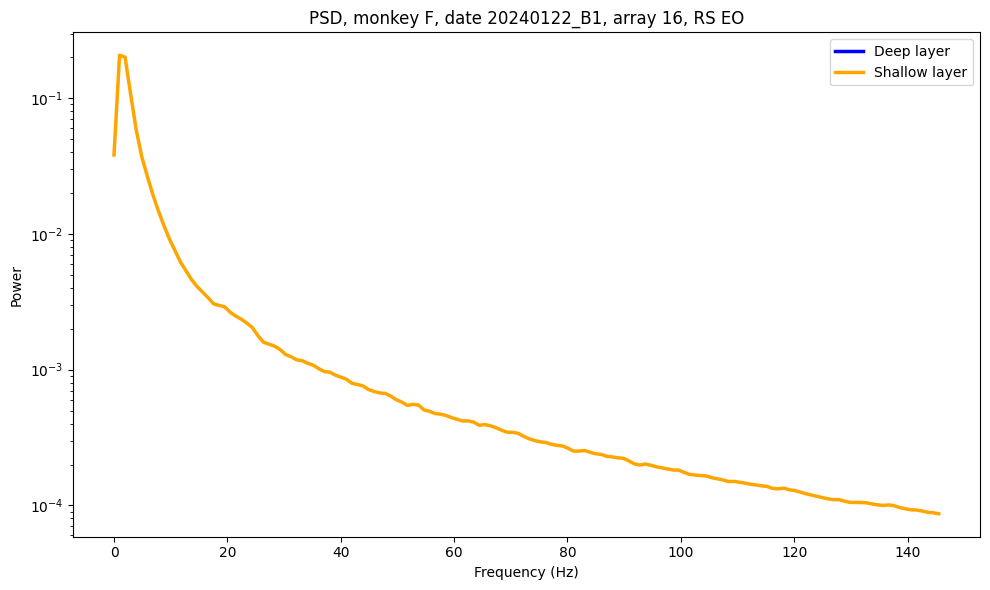

20241216_B1


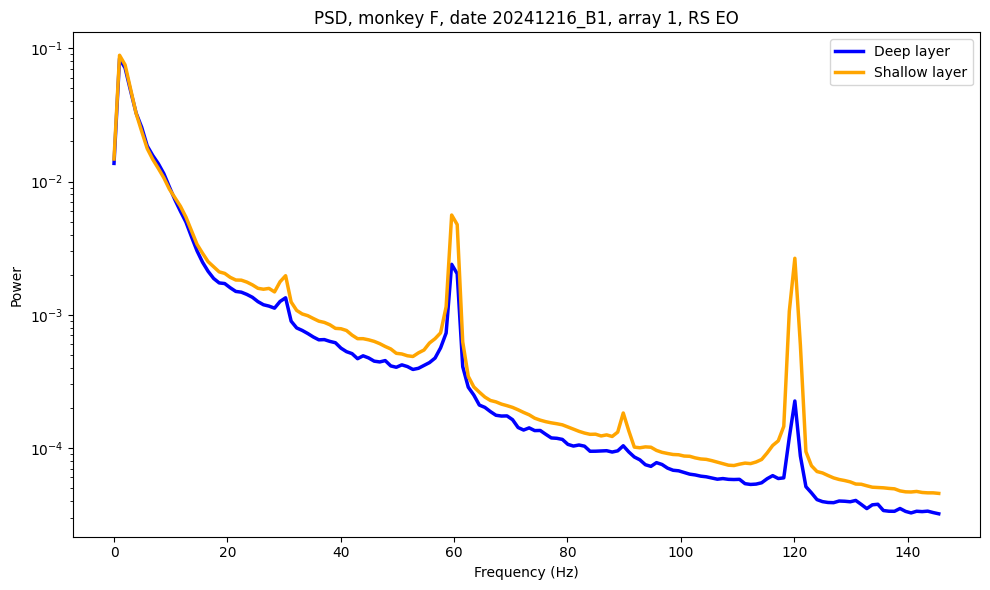

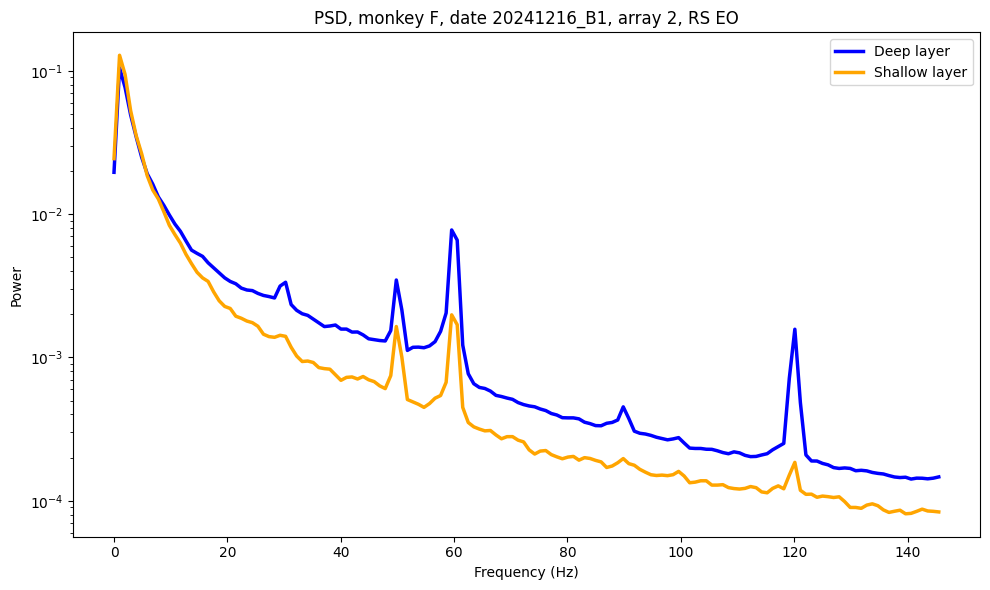

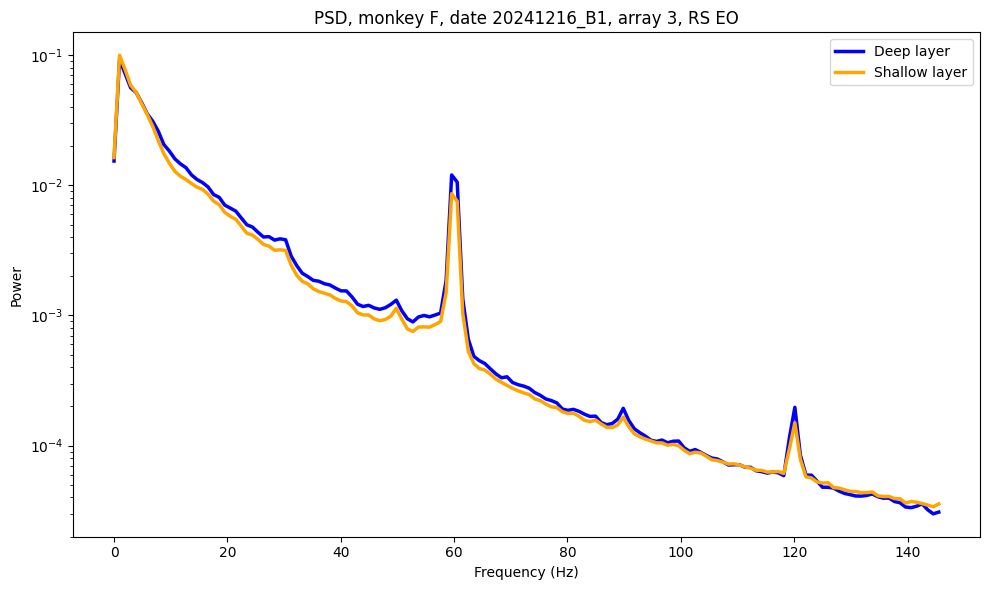

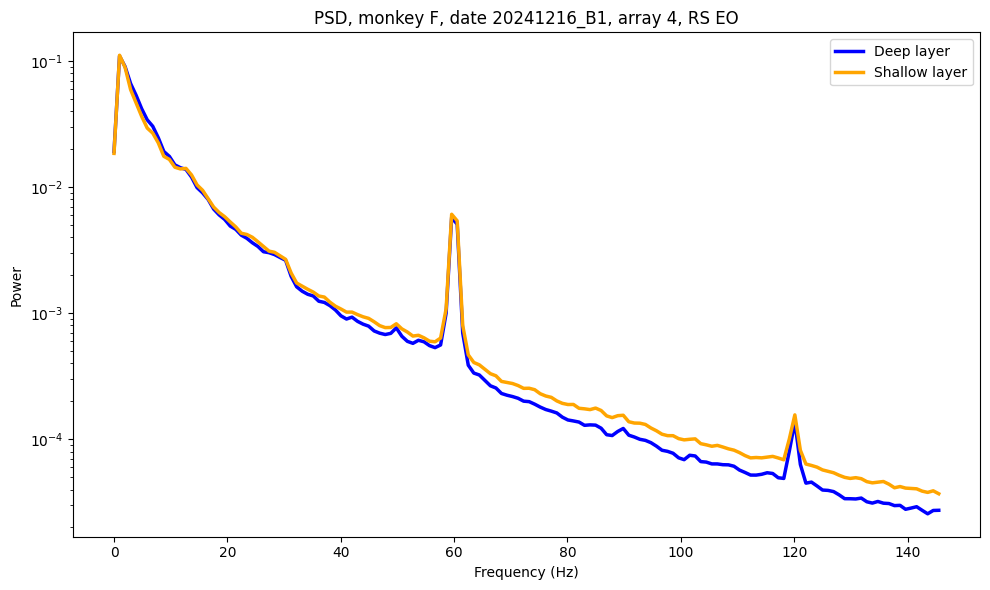

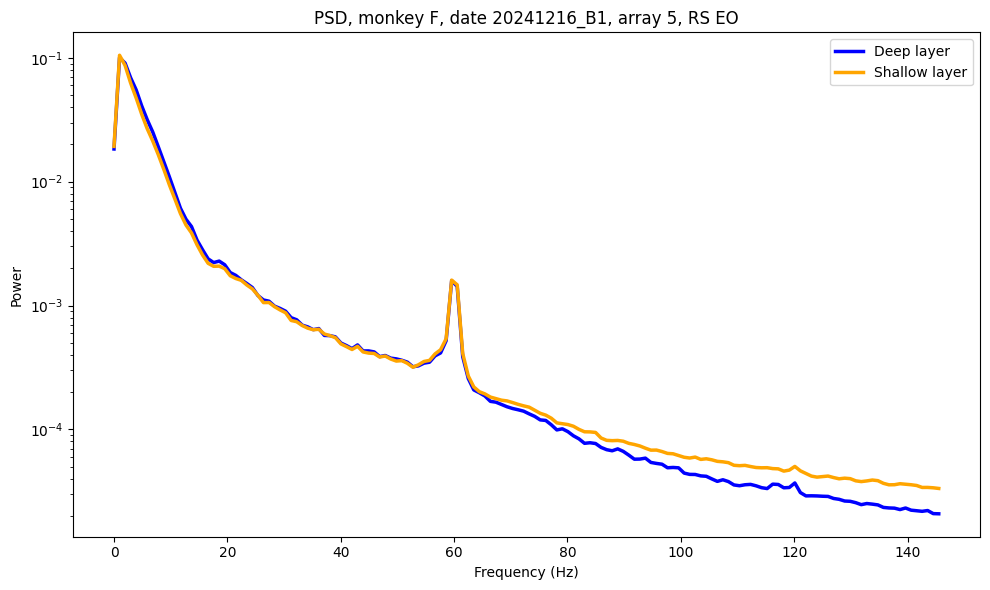

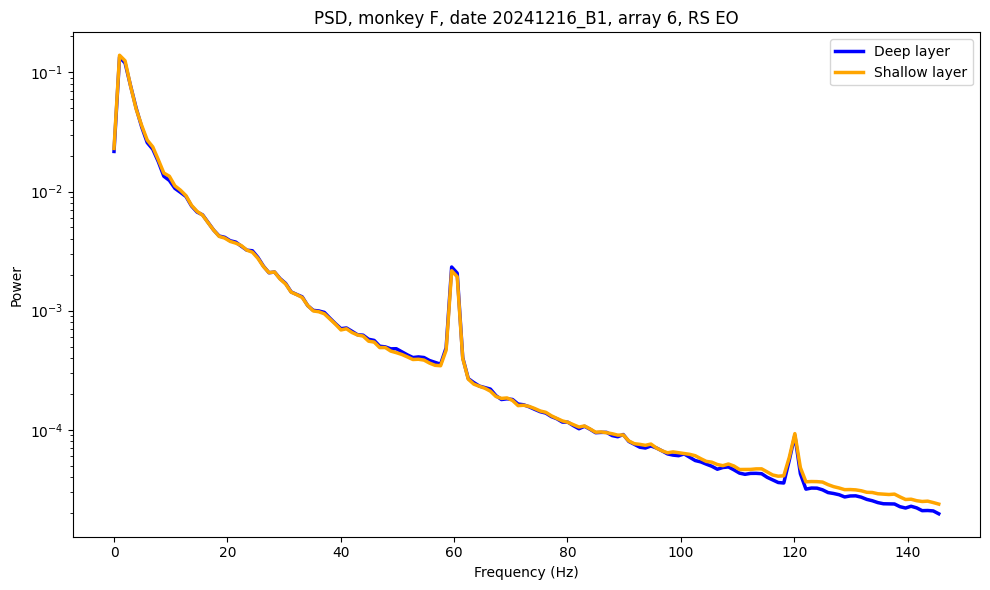

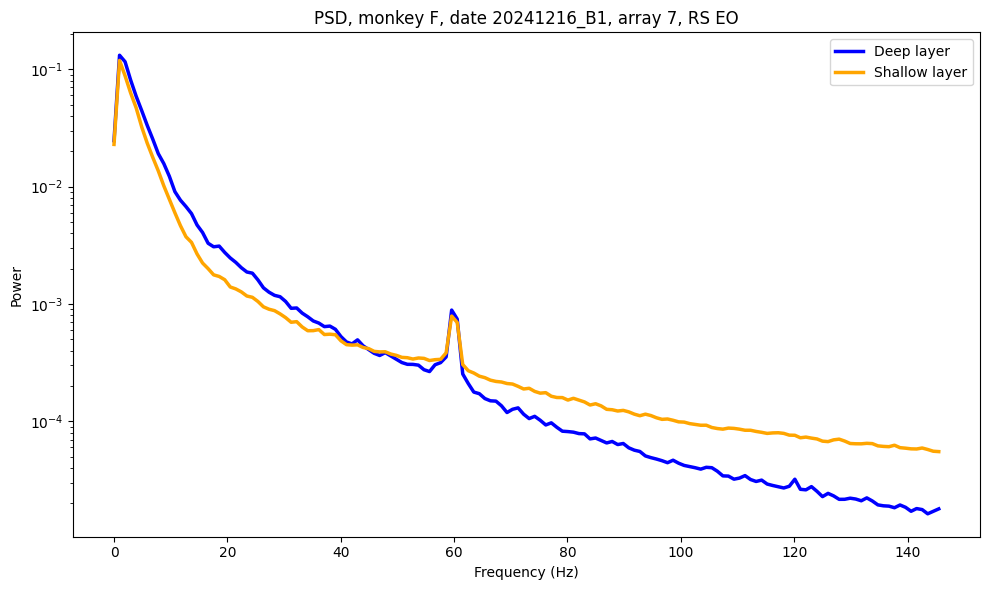

/tmp/ipykernel_2800875/2310349909.py:30: RuntimeWarning: Mean of empty slice.
  mean_blue_psd = blue_psds.mean(axis=0)
/home/studekat/virt_env/work/lib/python3.12/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


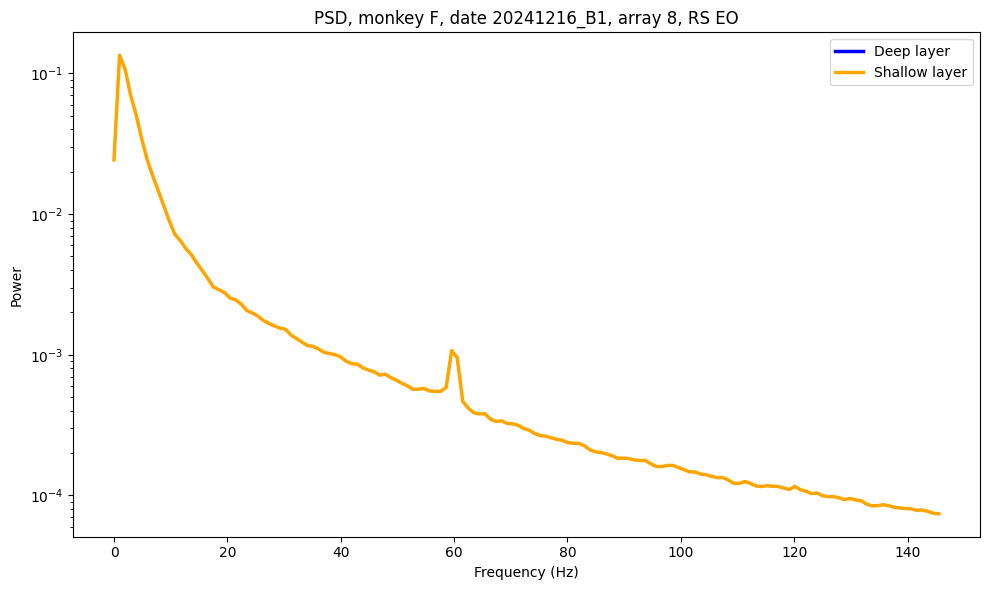

/tmp/ipykernel_2800875/2310349909.py:30: RuntimeWarning: Mean of empty slice.
  mean_blue_psd = blue_psds.mean(axis=0)
/home/studekat/virt_env/work/lib/python3.12/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


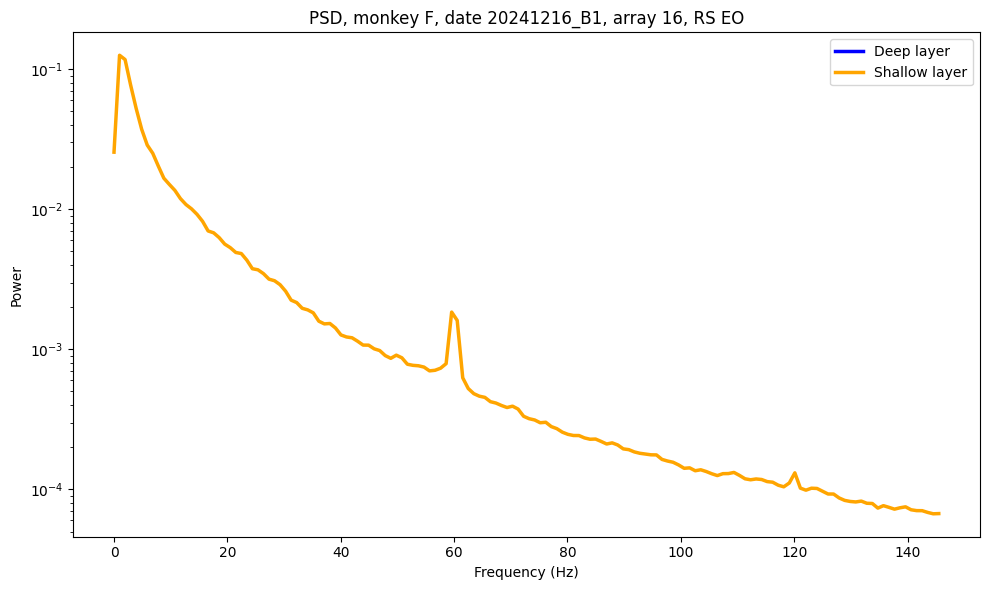

In [15]:
for monkey in MONKEY_LIST:
    print(monkey)
    for date in params_analysis['dates'][monkey]['RS']:
        print(date)
        # SUA csv, given date
        with open(f'{DF_FOLDER}/sua_prop_all/monkey{monkey}_all_arrays_date_{date}.pkl', "rb") as file:
            df_sua = pickle.load(file)
        # eyes indicator
        file_path = f'{MAIN_FOLDER}/metadata/EC_EO_indicators/eyes_indic_monkey_{monkey}_RS_date_{date}_common_times.pkl'
        with open(file_path, 'rb') as file:
            eyes_dict = pickle.load(file)
        for array in range(1,17):
            try:
                if params_analysis['areas'][monkey][array-1] in ['V1','V2']:
                    # LFP - given array, given date
                    lfp_bl = load_block(monkey,array,'RS','LFP',date,DATA_FOLDER)
                    EO_indic = eyes_dict['EO'].astype(bool)
                    lfp_EO = cut_out_LFP_EO(lfp_bl,monkey,date,EO_indic,params_analysis)
                    ch_dict = aux_units_on_ch(df_sua,array,final_classes=FINAL_CLASSES)
                    clique_dict = aux_dominant_clique_on_ch(ch_dict)
                    blue_keys, orange_keys = aux_split_idx(clique_dict)
                    blue_lfps, orange_lfps, other_lfps = aux_split_lfp(lfp_EO,blue_keys,orange_keys)
                    blue_psds, f = spectrum_list(blue_lfps,NPERSEG)
                    orange_psds, f = spectrum_list(orange_lfps,NPERSEG)
    
                    N=150
                    plt.figure(figsize=(10, 6))
                    
                    # plot the average psds
                    mean_blue_psd = blue_psds.mean(axis=0)
                    plt.semilogy(f[:N], mean_blue_psd[:N], color='blue', linewidth=2.5, label='Deep layer')
                    mean_orange_psd = orange_psds.mean(axis=0)
                    plt.semilogy(f[:N], mean_orange_psd[:N], color='orange', linewidth=2.5, label='Shallow layer')
                    
                    plt.xlabel("Frequency (Hz)")
                    plt.ylabel("Power")
                    plt.title(f"PSD, monkey {monkey}, date {date}, array {array}, RS EO")
                    plt.legend()
                    plt.tight_layout()
                    plt.show()
            except:
                print(f'Array {array} not used.')


## Pooling spectra 

In [16]:
NPERSEG = 1024

In [17]:
blue_psd_dict = {m: [] for m in MONKEY_LIST}
orange_psd_dict = {m: [] for m in MONKEY_LIST}
for monkey in MONKEY_LIST:
    print(monkey)
    for date in params_analysis['dates'][monkey]['RS']:
        print(date)
        # SUA csv, given date
        with open(f'{DF_FOLDER}/sua_prop_all/monkey{monkey}_all_arrays_date_{date}.pkl', "rb") as file:
            df_sua = pickle.load(file)
        df_sua = df_sua[~df_sua['ch_is_noisy_120Hz']]
        df_sua = df_sua[~df_sua['ch_is_noisy_100Hz']]
        # eyes indicator
        file_path = f'{MAIN_FOLDER}/metadata/EC_EO_indicators/eyes_indic_monkey_{monkey}_RS_date_{date}_common_times.pkl'
        with open(file_path, 'rb') as file:
            eyes_dict = pickle.load(file)
        for array in range(1,17):
            try:
                if params_analysis['areas'][monkey][array-1] in ['V1','V2']:
                    # LFP - given array, given date
                    lfp_bl = load_block(monkey,array,'RS','LFP',date,DATA_FOLDER)
                    EO_indic = eyes_dict['EO'].astype(bool)
                    lfp_EO = cut_out_LFP_EO(lfp_bl,monkey,date,EO_indic,params_analysis)
                    ch_dict = aux_units_on_ch(df_sua,array,final_classes=FINAL_CLASSES)
                    clique_dict = aux_dominant_clique_on_ch(ch_dict)
                    blue_keys, orange_keys = aux_split_idx(clique_dict)
                    blue_lfps, orange_lfps, other_lfps = aux_split_lfp(lfp_EO,blue_keys,orange_keys)
                    blue_psds, f = spectrum_list(blue_lfps,NPERSEG)
                    orange_psds, f = spectrum_list(orange_lfps,NPERSEG)
                    blue_psd_dict[monkey].append(blue_psds)
                    orange_psd_dict[monkey].append(orange_psds)
            except:
                print(f'Array {array} not used.')

L
20170725
20170809
20170810
F
20240122_B1
20241216_B1


## Testing - geom. averages - final plot org.

In [18]:
# Alpha: 10-20
# Gamma: 70-90
ALPHA = [10,20]
GAMMA = [70,90]
MEAN_ARR = False

In [19]:
alpha_data_all = {}
gamma_data_all = {}
p_alpha_all = {}
p_gamma_all = {}

for monkey in MONKEY_LIST:
    blue_alpha = aux_pick_f_psd(blue_psd_dict, monkey, f,ALPHA[0], ALPHA[1], mean_for_array=MEAN_ARR)
    orange_alpha = aux_pick_f_psd(orange_psd_dict, monkey,f, ALPHA[0], ALPHA[1], mean_for_array=MEAN_ARR)
    blue_gamma = aux_pick_f_psd(blue_psd_dict, monkey, GAMMA[0],f, GAMMA[1], mean_for_array=MEAN_ARR)
    orange_gamma = aux_pick_f_psd(orange_psd_dict, monkey, GAMMA[0],f, GAMMA[1], mean_for_array=MEAN_ARR)

    # geometric means
    gm_blue_alpha = gmean(blue_alpha, axis=1)
    gm_orange_alpha = gmean(orange_alpha, axis=1)
    gm_blue_gamma = gmean(blue_gamma, axis=1)
    gm_orange_gamma = gmean(orange_gamma, axis=1)

    alpha_data_all[monkey] = [gm_blue_alpha, gm_orange_alpha]
    gamma_data_all[monkey] = [gm_blue_gamma, gm_orange_gamma]

    # stats
    p_alpha_all[monkey] = mannwhitneyu(gm_blue_alpha, gm_orange_alpha, alternative='greater').pvalue
    p_gamma_all[monkey] = mannwhitneyu(gm_blue_gamma, gm_orange_gamma, alternative='less').pvalue

In [20]:
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 0))
formatter.set_useOffset(True)

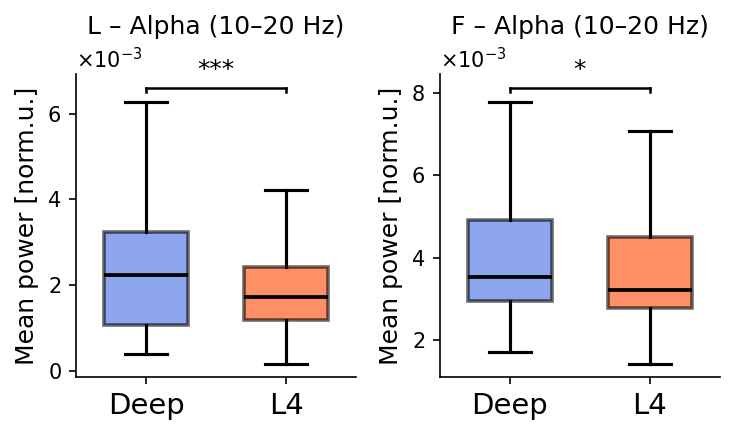

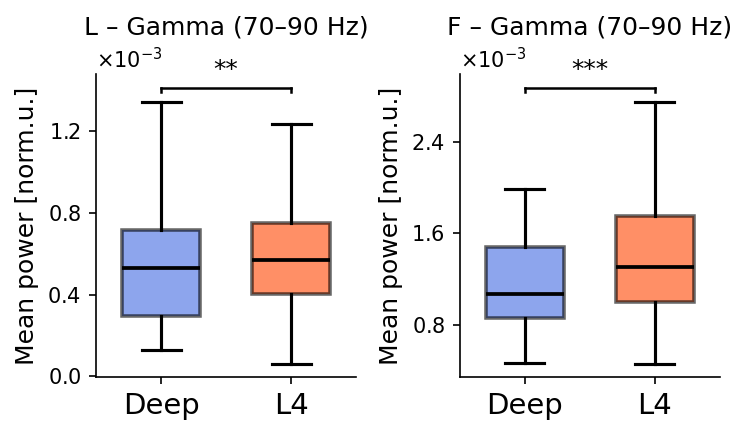

In [21]:
fig_alpha, axes_alpha = plt.subplots(1, len(MONKEY_LIST),
                                     figsize=(2.5 * len(MONKEY_LIST), 3),dpi=150)

if len(MONKEY_LIST) == 1:
    axes_alpha = [axes_alpha]  # ensure iterable

for col, monkey in enumerate(MONKEY_LIST):

    ax = axes_alpha[col]

    bp = ax.boxplot(alpha_data_all[monkey],
                    tick_labels=["Deep", "L4"],
                    showfliers=False,
                    patch_artist=True,
                    widths=0.6)
    ax.tick_params(axis='x', labelsize=14)

    # Colors
    for patch, color in zip(bp["boxes"], ["royalblue", "orangered"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    # Style boxplot lines
    for box in bp["boxes"]:
        box.set_linewidth(1.7)
    
    for whisker in bp["whiskers"]:
        whisker.set_linewidth(1.5)
    
    for cap in bp["caps"]:
        cap.set_linewidth(1.5)
    
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.8)

    # Significance bar
    add_sig_bar_from_boxplot(ax, bp, p_alpha_all[monkey])

    # Title
    ax.set_title(f"{monkey} – Alpha (10–20 Hz)")

    # Axis formatting
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel("Mean power [norm.u.]",fontsize=12)
    ax.yaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_formatter(formatter)

fig_alpha.tight_layout()
plt.show()

fig_gamma, axes_gamma = plt.subplots(1, len(MONKEY_LIST),
                                     figsize=(2.5 * len(MONKEY_LIST), 3),dpi=150)

if len(MONKEY_LIST) == 1:
    axes_gamma = [axes_gamma]

for col, monkey in enumerate(MONKEY_LIST):

    ax = axes_gamma[col]

    bp = ax.boxplot(gamma_data_all[monkey],
                    tick_labels=["Deep", "L4"],
                    showfliers=False,
                    patch_artist=True,
                    widths=0.6)
    ax.tick_params(axis='x', labelsize=14)

    # Colors
    for patch, color in zip(bp["boxes"], ["royalblue", "orangered"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

     # Style boxplot lines
    for box in bp["boxes"]:
        box.set_linewidth(1.7)
    
    for whisker in bp["whiskers"]:
        whisker.set_linewidth(1.5)
    
    for cap in bp["caps"]:
        cap.set_linewidth(1.5)
    
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.8)

    # Significance bar
    add_sig_bar_from_boxplot(ax, bp, p_gamma_all[monkey])

    # Title
    ax.set_title(f"{monkey} – Gamma (70–90 Hz)")

    # Axis formatting
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel("Mean power [norm.u.]",fontsize=12)
    ax.yaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_formatter(formatter)

fig_gamma.tight_layout()
plt.show()


In [22]:
# p-vals 
for monkey in ['L','F']:
    print(f'Monkey {monkey}, Alpha:{p_alpha_all[monkey]}')
    print(f'Monkey {monkey}, Gamma:{p_gamma_all[monkey]}')

Monkey L, Alpha:2.4706620300393804e-05
Monkey L, Gamma:0.003245324145219843
Monkey F, Alpha:0.03801944951504704
Monkey F, Gamma:9.648422574558605e-06


In [30]:
print(len(alpha_data_all['L'][0]))
print(len(alpha_data_all['L'][1]))

276
626


In [31]:
print(len(alpha_data_all['F'][0]))
print(len(alpha_data_all['F'][1]))

125
196
